In [1]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import pvlib
from pvlib import location, pvsystem, modelchain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import re


# -----------------------------------------------------------------------------
# 1. Data Loading & Generation (Same as Mamba)
# -----------------------------------------------------------------------------


import pandas as pd
import re

import pandas as pd
import numpy as np
import re
from pvlib import location, pvsystem, modelchain
from pvlib.modelchain import ModelChain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

def get_station_metadata(station_num, df):
    """
    Retrieves and parses metadata for a specific station from the DataFrame.
    
    Args:
        station_num (int or str): The station number (e.g., 5 or '05').
        df (pd.DataFrame): The source dataframe containing station metadata.
        
    Returns:
        dict: A clean dictionary with numerical values ready for simulation.
    """
    
    # 1. Format the station ID
    station_id_str = f"station{str(station_num).zfill(2)}"
    
    # 2. Filter the dataframe
    station_row = df[df['Station_ID'] == station_id_str]
    
    if station_row.empty:
        raise ValueError(f"Station ID {station_id_str} not found in DataFrame.")
    
    # Get the single row as a Series
    row = station_row.iloc[0]

    # --- Helper 1: Parse "Key:Value" blocks (lines separated by \n) ---
    def parse_kv_string(text_block):
        data = {}
        if isinstance(text_block, str):
            for item in text_block.split('\n'):
                if ':' in item:
                    k, v = item.split(':', 1)
                    data[k.strip()] = v.strip()
        return data

    # --- Helper 2: Extract numeric values safely (e.g., "250 Wp" -> 250.0) ---
    def extract_num(val, default=0.0):
        if pd.isna(val): return default
        match = re.search(r"[-+]?\d*\.\d+|\d+", str(val))
        return float(match.group()) if match else default

    # 3. Parse complex text columns into dictionaries
    module_items = parse_kv_string(row.get('Module', ''))
    inverter_items = parse_kv_string(row.get('Inverters', ''))
    layout_items = parse_kv_string(row.get('Layout', ''))

    # 4. Build the final clean dictionary
    # We use extract_num to ensure we pass numbers (floats/ints) to the model, not strings.
    metadata = {
        # --- Identity & Location ---
        'Station_ID': station_id_str,
        'Longitude': float(row['Longitude']),
        'Latitude': float(row['Latitude']),
        'Array_Tilt': row['Array_Tilt'], # Kept as string (e.g., "South 30") for parsing in main model
        
        # --- System Capacity & Dimensions ---
        'Capacity': float(row['Capacity']),          # Total Station Capacity (kW)
        'Panel_Size': float(row.get('Panel_Size', 1.62)), # Panel Area in m^2
        'Total_Panel_Number': int(row.get('Panel_Number', 0)),
        'PV_Technology': row['PV_Technology'],

        # --- Extracted Module Specs (Cleaned to Float) ---
        'Module_Pmax': extract_num(module_items.get('Pmax'), default=250),
        'Module_Vmpp': extract_num(module_items.get('Vmpp'), default=30),
        'Module_Impp': extract_num(module_items.get('Impp'), default=8),
        
        # --- Extracted Inverter Specs (Cleaned to Float) ---
        'Inverter_Rated_Power': extract_num(inverter_items.get('Rated power'), default=500),
        'Inverter_Max_DC_Voltage': extract_num(inverter_items.get('Max. DC voltage'), default=1000),
        
        # --- Extracted Layout Specs (Cleaned to Int) ---
        # Note: Layout strings can look like "modules per string:20"
        'Modules_per_String': int(extract_num(layout_items.get('modules per string'), default=20)),
        'Strings_per_Inverter': int(extract_num(layout_items.get('strings per inverter'), default=100)),
    }
    
    return metadata


def calculate_clearsky_indices(metadata, df):
    """
    Calculates both Irradiance (K_CS) and Power (K_PV) Clear Sky Indices.
    
    Args:
        metadata (dict): Parsed station metadata.
        df (pd.DataFrame): Time-series data with 'lmd_totalirrad' and 'power' columns.
                           'power' should be in MW (or kW, logic adapts).
                           'lmd_totalirrad' should be in W/m^2.
    
    Returns:
        pd.DataFrame: Original df with added columns 'GHI_clr', 'K_CS', 'P_CLR', 'K_PV'.
    """
    
    print(f"--- Processing {metadata.get('Station_ID', 'Unknown')} ---")
    
    # ---------------------------------------------------------
    # 1. SETUP LOCATION & TIME
    # ---------------------------------------------------------
    # The paper explicitly states timestamps are in Coordinated Universal Time (UTC).
    # Setting tz='UTC' ensures pvlib aligns Solar Noon correctly (approx 04:00 UTC for China).
    lat = metadata['Latitude']
    lon = metadata['Longitude']
    
    site = location.Location(lat, lon, tz='UTC')
    
    # Ensure index is Datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df['date_time'] = pd.to_datetime(df['date_time'])
        df.set_index('date_time', inplace=True)

    # ---------------------------------------------------------
    # 2. CALCULATE CLEAR SKY IRRADIANCE (GHI_clr)
    # ---------------------------------------------------------
    print("Calculating Clear Sky Irradiance (Ineichen model)...")
    
    # Calculate theoretical GHI (returns W/m^2)
    cs = site.get_clearsky(df.index, model='ineichen')
    df['GHI_clr'] = cs['ghi']

    # --- Index 1: Irradiance Clear Sky Index (K_CS) ---
    # Formula: K_CS = Measured GHI / Clear Sky GHI
    
    if 'lmd_totalirrad' in df.columns:
        # Standardize Measured Units: 
        # lmd_totalirrad is W/m^2.
        meas_ghi = df['lmd_totalirrad']
        

        # Calculate Index (Filter: Only when model expects sun > 10 W/m^2)
        # Naive filter to avoid night time noise
        df['K_CS_day'] = np.where(
            df['GHI_clr'] > 10, 
            meas_ghi / df['GHI_clr'], 
            0.0
        )
        df['K_CS_dayNight'] = meas_ghi / df['GHI_clr']

        df['K_CS'] = df['K_CS_day']
        
        # Clip outliers (cloud edge effects can cause > 1.0)
        df['K_CS'] = df['K_CS'].clip(lower=0.0, upper=1.25)
    else:
        print("Warning: 'lmd_totalirrad' column missing. K_CS not calculated.")

    # ---------------------------------------------------------
    # 3. SETUP PV SYSTEM MODEL (For P_CLR)
    # ---------------------------------------------------------
    # Extract Tilt safely from string 
    try:
        tilt_str = str(metadata.get('Array_Tilt'))
        tilt_match = re.search(r"[\d.]+", tilt_str)
        tilt = float(tilt_match.group()) if tilt_match else 33.0
    except Exception as e:
        print(f"Error extracting tilt: {e} .... Assuming 33 degrees")
        tilt = 33.0
    
    # Default Azimuth: 180 (South) for Northern Hemisphere
    azimuth = 180 

    # Define Module Parameters (Generic Poly-Si based on metadata)
    # Hard coded Module for specific station 07
    module_params = pvsystem.retrieve_sam('CECMod')['Yingli_Energy__China__YL250P_29b']
    # Module Parameters can be retreived from pvsystem.retrieve_sam by defining the module name and for now for simplicity we use hardcoded one.
    # module_params = {
    #     'pdc0': metadata['Module_Pmax'],   # STC Power (Watts)
    #     'gamma_pdc': -0.004,               # Temp coeff
    #     'b': 0.05, 'a': -3.56              # Sandia model defaults
    # }
    
    # Define Inverter Parameters (One Block)
    # Block Size = Modules per string * Strings per inverter * Module Power
    block_dc_watts = (metadata['Modules_per_String'] * metadata['Strings_per_Inverter'] * metadata['Module_Pmax'])
    

    # The same with Inverter infoirmation i used hardcoded info for station 07    
    # inv_params = pvsystem.retrieve_sam("cecinverter")

    ivt_para = pvsystem.retrieve_sam('cecinverter')['Advanced_Energy_Industries__Solaron_500kW__3159500_XXXX___480V_']
    ivt_para["Pdco"], ivt_para['Vdco'], ivt_para["Vdcmax"], ivt_para['Idcmax'], = 567000, 315, 1000, 1134
    ivt_para["Mppt_low"], ivt_para['Mppt_high'] = 460, 950
    inverter_parameters = ivt_para
    
    # Temperature Model (Open Rack)
    temp_model = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']
    
    system = pvsystem.PVSystem(
        surface_tilt=tilt,
        surface_azimuth=azimuth,
        module_parameters=module_params,
        inverter_parameters=inverter_parameters,
        temperature_model_parameters=temp_model,
        modules_per_string=metadata['Modules_per_String'],
        strings_per_inverter=metadata['Strings_per_Inverter']
        # modules_per_string=20, strings_per_inverter=100 # Must be retreived from metadata, but for now hardcoded
    )

    # ---------------------------------------------------------
    # 4. RUN MODEL CHAIN FOR POWER
    # ---------------------------------------------------------
    print("Running PV Power Simulation...")

    mc = ModelChain(system, site, transposition_model='perez',
                        solar_position_method='nrel_numpy',
                        aoi_model='physical', spectral_model='no_loss')

    # mc = modelchain.ModelChain(
    #     system, 
    #     site, 
    #     aoi_model='physical', 
    #     spectral_model='no_loss', 
    #     ac_model='pvwatts'
    # )

    # Run using the Clear Sky weather data
    mc.run_model(cs)

    # ---------------------------------------------------------
    # 5. SCALE & CALCULATE POWER INDEX (K_PV)
    # ---------------------------------------------------------
    # The simulation (mc.results.ac) is for ONE Block. Scale to full station.
    
    station_total_capacity_watts = metadata['Capacity'] * 1000  # kW -> Watts [cite: 109]
    scaling_factor = station_total_capacity_watts / block_dc_watts
    
    # Calculate Station Clear Sky Power (MW)
    # FillNa(0) handles night time; Divide by 1M to get MW
    p_clr_watts = mc.results.ac.fillna(0) * scaling_factor
    df['P_CLR'] = p_clr_watts / 1_000_000 

    # --- Index 2: Power Clear Sky Index (K_PV) ---
    # Formula: K_PV = Measured Power / Clear Sky Power
    
    if 'power' in df.columns:
        meas_power = df['power']
        
        # Check units: Paper says Power is MW[cite: 109].
        # Heuristic: If max > 500, it is likely kW, so divide by 1000.
        if meas_power.max() > 500:
            meas_power = meas_power / 1000.0
            
        # Calculate Index
        # Filter: Only calculate when model expects > 0.05 MW to avoid night noise
        df['K_PV'] = np.where(
            df['P_CLR'] > 1.0, 
            meas_power / df['P_CLR'], 
            0.0
        )
        
        # Clip for cleanliness (Values > 1.0 mean better than clear sky or model error)
        df['K_PV'] = df['K_PV'].clip(lower=0.0, upper=1.5)
    else:
        print("Warning: 'power' column missing. K_PV not calculated.")

    return df


# ==========================================================
# Real Power PV generated power data.

# read the data for PVOD
abs_path = os.path.abspath("../PVODdatasets_v1")

station07_path = os.path.join(abs_path, "station07.csv")
station07_data = pd.read_csv(station07_path)

metadata_path = os.path.join(abs_path, "metadata.csv")
metaData = pd.read_csv(metadata_path)


station07_metaData = get_station_metadata(7, metaData)
station07_data = pd.read_csv(station07_path)

station07_df = calculate_clearsky_indices(station07_metaData, station07_data)



--- Processing station07 ---
Calculating Clear Sky Irradiance (Ineichen model)...
Running PV Power Simulation...


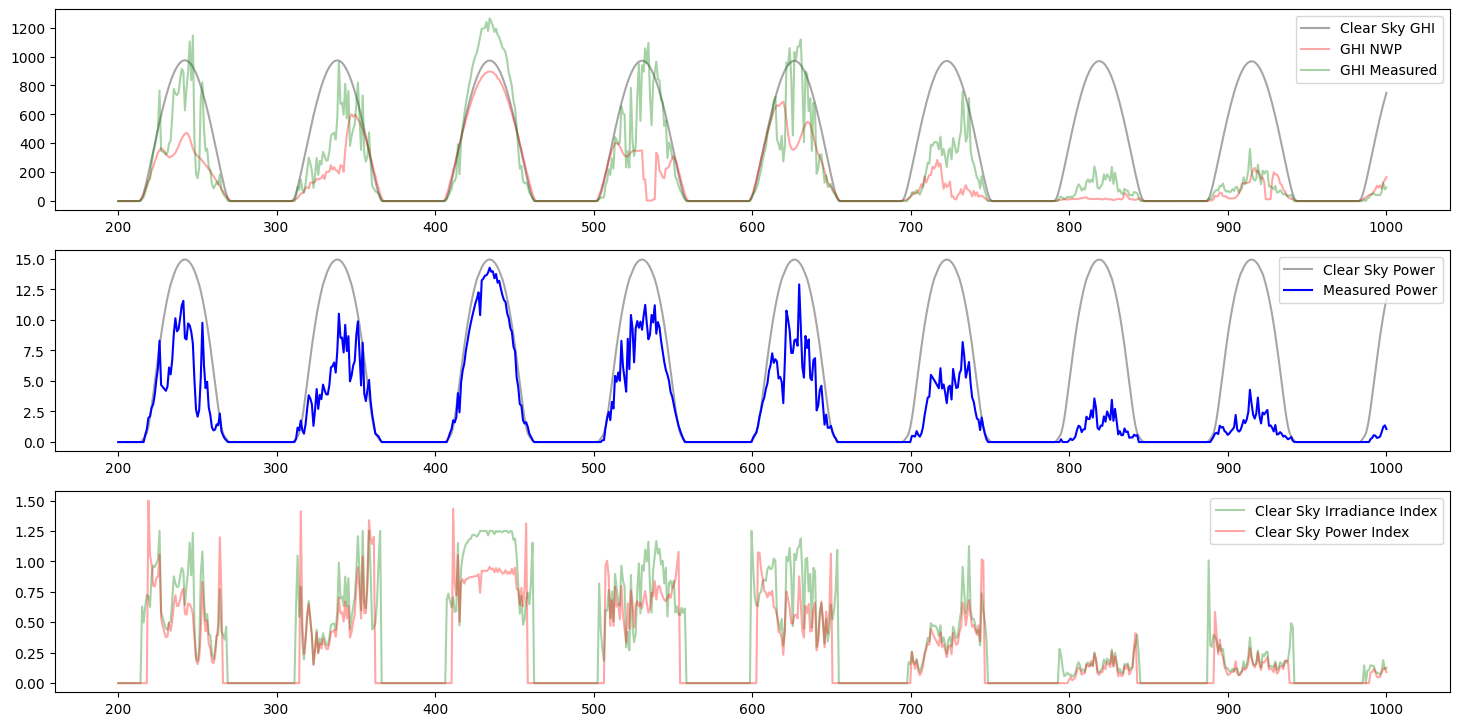

In [2]:
points = 1000
t = np.linspace(0, points, points)
start = 200

plt.figure(figsize=(18, 12))
plt.subplot(4, 1, 1)
plt.plot(t[start:points], station07_df['GHI_clr'][start:points], label='Clear Sky GHI', color='black', alpha=0.35)
plt.plot(t[start:points], station07_df['nwp_globalirrad'][start:points], label='GHI NWP', color='red', alpha=0.35)
plt.plot(t[start:points], station07_df['lmd_totalirrad'][start:points], label='GHI Measured', color='green', alpha=0.35)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t[start:points], station07_df['P_CLR'][start:points], label='Clear Sky Power', color='black', alpha=0.35)
plt.plot(t[start:points], station07_df['power'][start:points], label='Measured Power', color='blue')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t[start:points], station07_df['K_CS'][start:points], label='Clear Sky Irradiance Index', color='green', alpha=0.35)
plt.plot(t[start:points], station07_df['K_PV'][start:points], label='Clear Sky Power Index', color='red', alpha=0.35)
plt.legend()


plt.show()

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        # REASONING: We repeat the first value to "pad" the start, 
        # and the last value to "pad" the end. 
        # This keeps the output length equal to input length.
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x

class series_decomp(nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean



# Adding Prediction into the past.

# Wavelet Transform

In [6]:
station07_df.columns

Index(['nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
       'nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'lmd_totalirrad',
       'lmd_diffuseirrad', 'lmd_temperature', 'lmd_pressure',
       'lmd_winddirection', 'lmd_windspeed', 'power', 'GHI_clr', 'K_CS_day',
       'K_CS_dayNight', 'K_CS', 'P_CLR', 'K_PV'],
      dtype='object')

In [77]:
class moving_avg(torch.nn.Module):
    """
    Moving average block to highlight the trend of time series
    """
    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = torch.nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x
        

class series_decomp(torch.nn.Module):
    """
    Series decomposition block
    """
    def __init__(self, kernel_size):
        super(series_decomp, self).__init__()
        self.moving_avg = moving_avg(kernel_size, stride=1)

    def forward(self, x):
        moving_mean = self.moving_avg(x)
        res = x - moving_mean
        return res, moving_mean


decompsition = series_decomp(3)

In [98]:
import torch
import torch.nn.functional as F
import pywt

def calculate_pytorch_wavelet(x, wavelet_name='db4'):
    batch_size, seq_len, num_channels = x.shape
    device = x.device # Ensure we use the same device as the input tensor

    # 1. Get Wavelet Filters
    wavelet = pywt.Wavelet(wavelet_name)
    
    # Fix: Access the high-pass decomposition filter (Detail filter)
    # Most pywt versions use dec_hi for high-pass and dec_lo for low-pass
    filter_data = wavelet.dec_hi if hasattr(wavelet, 'dec_hi') else wavelet.dec_h
    
    dec_h = torch.tensor(filter_data, dtype=torch.float32, device=device).flip(0)
    
    # 2. Reshape filter for Grouped Conv1d: [Out_Channels, 1, Filter_Width]
    # We use groups=num_channels so each feature is filtered by its own wavelet
    filter_weight = dec_h.view(1, 1, -1).repeat(num_channels, 1, 1)

    # 3. Prepare Input: [Batch, Channels, Time]
    x_t = x.permute(0, 2, 1)

    # 4. Apply Convolution
    padding_len = len(dec_h) // 2
    details = F.conv1d(x_t, filter_weight, padding=padding_len, groups=num_channels)

    # 5. Length Correction
    if details.shape[-1] > seq_len:
        details = details[:, :, :seq_len]
    elif details.shape[-1] < seq_len:
        details = F.pad(details, (0, seq_len - details.shape[-1]))

    # 6. Return back to [Batch, Time, Channels]
    return details.permute(0, 2, 1)

In [ ]:
start_index = 35
L = 3
H = 2

end_index_past = start_index + L
start_index_future = end_index_past
end_index_future = start_index_future + H
Enc_In = 3
K_PV_data = station07_df[['K_PV', 'nwp_globalirrad']][start_index:end_index_past] # L is 288 as Input length of the K_PV Feature
K_PV_target_data = station07_df['K_PV'][start_index_future:end_index_future] # H is 96 as Input length of the K_PV Feature

future_nwp_tensor = station07_df['nwp_globalirrad'][start_index_future:end_index_future] # H is 96 as Input length of the nwp_globalirrad Feature

batch_size = 1
x_pred = torch.zeros(batch_size, L + H, Enc_In) # a matrix that spans the Total Time (L+H) and includes Expanded Features.
x_pred[:, :L, :2] = torch.tensor(K_PV_data.values)
x_pred[:, L:, 1] = torch.tensor(future_nwp_tensor.values)

# Current shape of nwp values is (H,). We need [Batch, Channels, Time] -> [1, 1, 2]
future_nwp_tensor = torch.tensor(nwp_globalirrad_data.values).float().view(1, 1, H)

# ==========================================
# 2. Perform the Interpolation (The "Squash")
# ==========================================
# We resize from H=2 to L=3
# Input: [1, 1, 2], Output: [1, 1, 3]

import torch.nn.functional as F
shadow_past_interpolated = F.interpolate(
    future_nwp_tensor, 
    size=L, 
    mode='linear', 
    align_corners=False
)

# ==========================================
# 3. Fill the Shadow Column (Index 2)
# ==========================================

# A. Fill PAST Rows (0 to L) with the Interpolated values
# shadow_past_interpolated is [1, 1, 3]. We squeeze it to [1, 3] to fit x_pred
x_pred[:, :L, 2] = shadow_past_interpolated.squeeze(1)
# B. Fill FUTURE Rows (L to end) with the Actual Future values
# We just copy the original H values here
x_pred[:, L:, 2] = torch.tensor(nwp_globalirrad_data.values).float()

# Decomposition happens AFTER integrate the external predictions (Shadows), but BEFORE compress them.

# x is the expanded L+H tensor
seasonal_init, trend_init = decompsition(x_pred)

wavelet_init = calculate_pytorch_wavelet(x_pred) # Must be same shape: [1, 5, 3]

x_triple = torch.cat([seasonal_init, trend_init, wavelet_init], dim=1)


lin1_triple = torch.nn.Linear(3 * (L + H), L).to(x.device)

# 6. Apply Compression
x_temp = torch.permute(x_triple, (0, 2, 1)) # [1, 3, 15]
x_compressed = lin1_triple(x_temp)          # [1, 3, 3]
x_final = torch.permute(x_compressed, (0, 2, 1))

print(f"Triple Decomp Shape: {x_triple.shape}")
print(f"Final Output Shape:  {x_final.shape}")


lin1 = torch.nn.Linear(2*(H+L), H)
x_double = torch.cat([seasonal_init, trend_init], dim=1) # Combine them
x = torch.permute(x_double, (0, 2, 1))
x = lin1(x) # Compress from 2*(L+H) -> L
x = torch.permute(x, (0, 2, 1))


print(f"Double Decomp Shape: {x_double.shape}")
print(f"Final Output Shape:  {x.shape}")


Triple Decomp Shape: torch.Size([1, 15, 3])
Final Output Shape:  torch.Size([1, 3, 3])
Double Decomp Shape: torch.Size([1, 10, 3])
Final Output Shape:  torch.Size([1, 2, 3])


In [102]:
x_triple

tensor([[[-1.2003e-03, -1.0560e+01, -6.6951e+00],
         [ 7.1430e-04, -4.4833e+00,  0.0000e+00],
         [ 2.9093e-01,  5.5634e+00,  2.0085e+01],
         [-2.9044e-01, -3.9100e+00, -2.6780e+01],
         [ 0.0000e+00,  1.3390e+01,  1.3390e+01],
         [ 8.6746e-01,  5.9210e+02,  6.9349e+02],
         [ 8.6915e-01,  6.1770e+02,  7.0688e+02],
         [ 5.8039e-01,  6.5279e+02,  7.0688e+02],
         [ 2.9044e-01,  6.9070e+02,  7.1357e+02],
         [ 0.0000e+00,  7.1357e+02,  7.1357e+02],
         [ 4.9840e-02, -9.0744e+01, -1.0373e+02],
         [-4.1202e-01, -2.5834e-01, -2.6478e+01],
         [ 1.6503e-01,  2.0059e+02,  2.1943e+02],
         [ 1.6131e-01, -3.5492e+02, -3.4266e+02],
         [-1.0911e-02,  1.0209e+02,  1.0001e+02]]])

In [88]:
x

tensor([[[-6.1609e-01,  5.0594e-02],
         [-7.4146e+01,  2.7141e+02],
         [-1.0811e+02,  2.8737e+02]]], grad_fn=<AddBackward0>)

In [80]:
trend_init

tensor([[[8.6746e-01, 5.9210e+02, 6.9349e+02],
         [8.6915e-01, 6.1770e+02, 7.0688e+02],
         [5.8039e-01, 6.5279e+02, 7.0688e+02],
         [2.9044e-01, 6.9070e+02, 7.1357e+02],
         [0.0000e+00, 7.1357e+02, 7.1357e+02]]])

In [79]:
seasonal_init

tensor([[[-1.2003e-03, -1.0560e+01, -6.6951e+00],
         [ 7.1430e-04, -4.4833e+00,  0.0000e+00],
         [ 2.9093e-01,  5.5634e+00,  2.0085e+01],
         [-2.9044e-01, -3.9100e+00, -2.6780e+01],
         [ 0.0000e+00,  1.3390e+01,  1.3390e+01]]])

In [35]:
torch.tensor(nwp_globalirrad_data.values)

tensor([686.7900, 726.9600], dtype=torch.float64)

In [32]:
K_PV_data

,K_PV,nwp_globalirrad
date_time,,
2018-07-01 00:45:00,0.866259,581.54
2018-07-01 01:00:00,0.869860,613.22
2018-07-01 01:15:00,0.871319,658.35


In [33]:
nwp_globalirrad_data

date_time
2018-07-01 01:30:00    686.79
2018-07-01 01:45:00    726.96
Name: nwp_globalirrad, dtype: float64

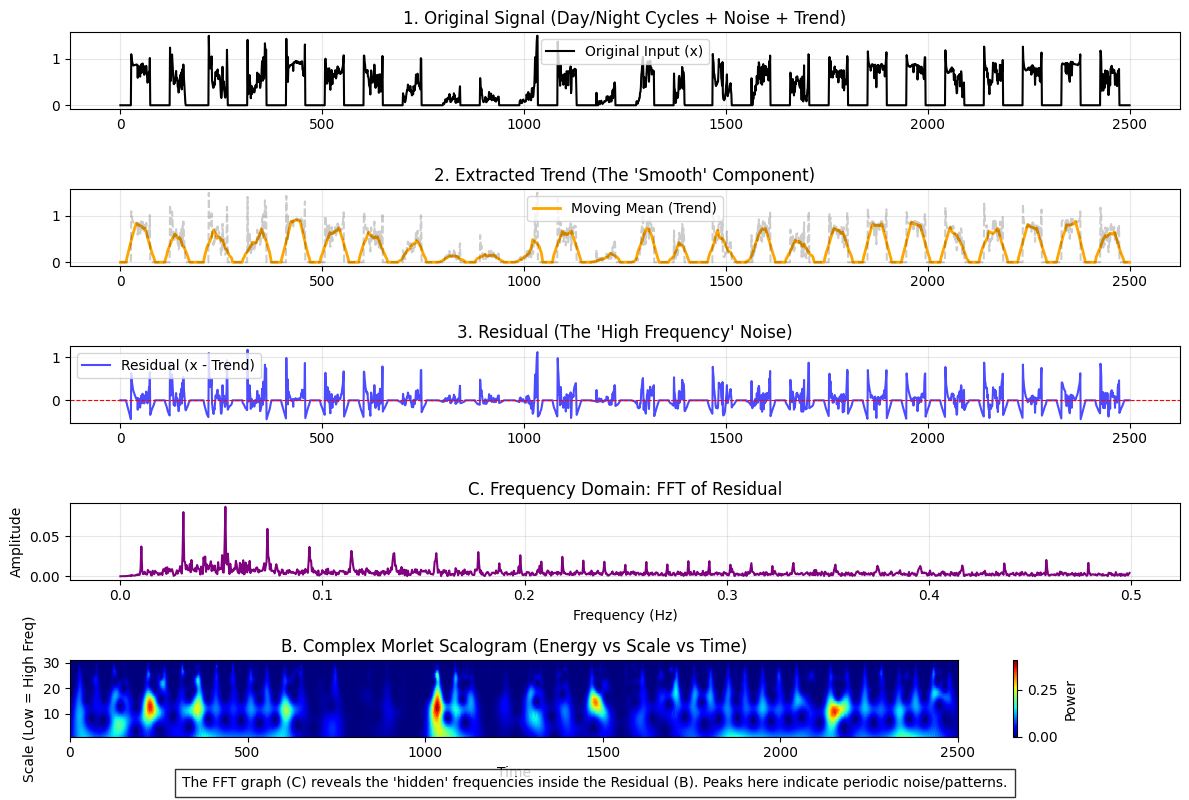

In [5]:

# --- 3. INVESTIGATION ---

# A. Prepare Data
K_PV_data = station07_df['K_PV'][:2500]
seq_len = len(K_PV_data)

t = np.linspace(0, seq_len, seq_len)

raw_data = K_PV_data.values

# Convert to PyTorch Tensor: [Batch=1, Length=200, Channels=1]
x_tensor = torch.tensor(raw_data, dtype=torch.float32).view(1, seq_len, 1)

# B. Initialize Decomposition Block
# Kernel Size = 25 (Controls how "smooth" the trend is)
# Since our "Day" is about 50 points long, 25 is a half-day average.
decomp_layer = series_decomp(kernel_size=25)

# C. Run the "Forward" Pass
residual, trend = decomp_layer(x_tensor)

# Detach for plotting
trend_np = trend.squeeze().detach().numpy()
res_np = residual.squeeze().detach().numpy()


from scipy.fft import fft, fftfreq

# --- 4. FFT ANALYSIS ON RESIDUAL ---
N = len(res_np)
T = t[1] - t[0]  # Sampling interval

# Compute FFT
yf = fft(res_np)
xf = fftfreq(N, T)[:N//2] # Frequencies (keep positive half)

# Compute Amplitude (Magnitude of FFT)
amplitude = 2.0/N * np.abs(yf[0:N//2])


# Morelet 

import pywt
# --- 4. MORLET WAVELET TRANSFORM (Using PyWavelets) ---
# Scales: Range from 1 to 30. 
# Note: 'cmor1.5-1.0' means Complex Morlet with bandwidth 1.5 and center freq 1.0
scales = np.arange(1, 31)
coefficients, frequencies = pywt.cwt(res_np, scales, 'cmor1.5-1.0', sampling_period=1)

# Calculate Power (Magnitude of complex coefficients)
power = (abs(coefficients)) ** 2

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 8))

# Plot 1: Original Noisy Data
plt.subplot(5, 1, 1)
plt.plot(t, raw_data, label='Original Input (x)', color='black')
plt.title("1. Original Signal (Day/Night Cycles + Noise + Trend)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Extracted Trend (Moving Mean)
plt.subplot(5, 1, 2)
plt.plot(t, trend_np, label='Moving Mean (Trend)', color='orange', linewidth=2)
plt.plot(t, raw_data, color='black', alpha=0.2, linestyle='--') # Show shadow of original
plt.title("2. Extracted Trend (The 'Smooth' Component)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Residuals (Noise)
plt.subplot(5, 1, 3)
plt.plot(t, res_np, label='Residual (x - Trend)', color='blue', alpha=0.7)
plt.title("3. Residual (The 'High Frequency' Noise)")
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True, alpha=0.3)


# Plot C: Frequency Domain (FFT of Residual)
plt.subplot(5, 1, 4)
plt.plot(xf, amplitude, color='purple')
plt.title("C. Frequency Domain: FFT of Residual")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)

# Add text explanation on plot
plt.figtext(0.5, 0.01, 
            "The FFT graph (C) reveals the 'hidden' frequencies inside the Residual (B). "
            "Peaks here indicate periodic noise/patterns.", 
            ha="center", fontsize=10, bbox={"facecolor":"white", "alpha":0.8, "pad":5})


# Plot B: The Scalogram (Time-Frequency Domain)
plt.subplot(5, 1, 5)
# We use 'power' here for better contrast
plt.imshow(power, extent=[0, seq_len, 1, 31], cmap='jet', aspect='auto', vmax=power.max(), vmin=0)
plt.title("B. Complex Morlet Scalogram (Energy vs Scale vs Time)")
plt.xlabel("Time")
plt.ylabel("Scale (Low = High Freq)")
plt.colorbar(label="Power")


plt.tight_layout()
plt.show()

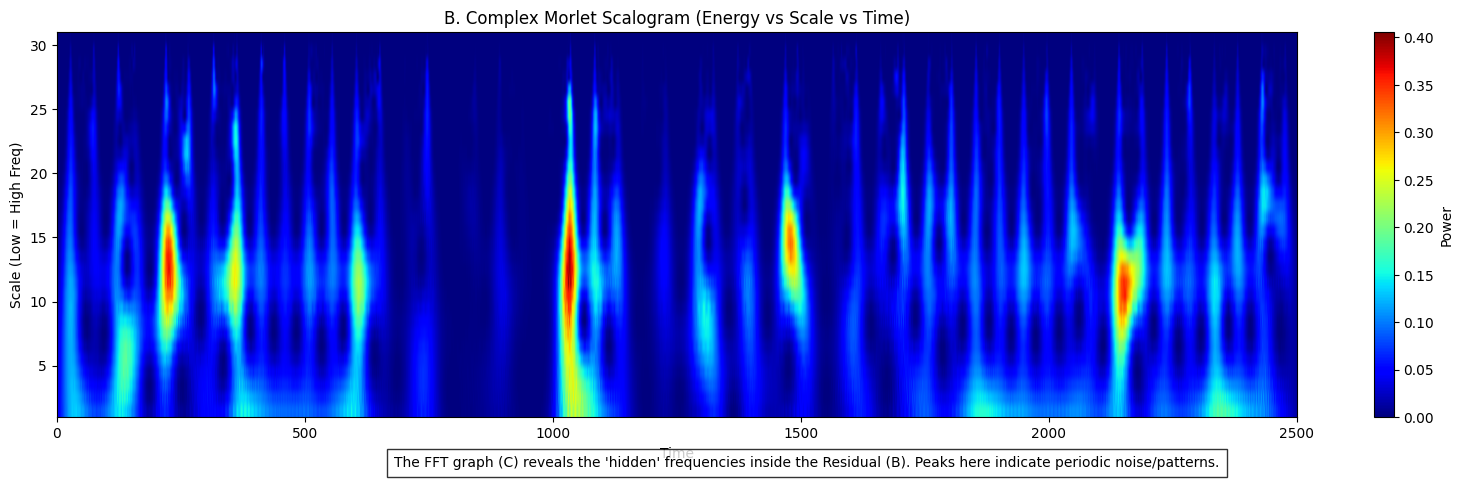

In [70]:
plt.figure(figsize=(20, 5))

# Add text explanation on plot
plt.figtext(0.5, 0.01, 
            "The FFT graph (C) reveals the 'hidden' frequencies inside the Residual (B). "
            "Peaks here indicate periodic noise/patterns.", 
            ha="center", fontsize=10, bbox={"facecolor":"white", "alpha":0.8, "pad":5})


# Plot B: The Scalogram (Time-Frequency Domain)
# We use 'power' here for better contrast
plt.imshow(power, extent=[0, seq_len, 1, 31], cmap='jet', aspect='auto', vmax=power.max(), vmin=0)
plt.title("B. Complex Morlet Scalogram (Energy vs Scale vs Time)")
plt.xlabel("Time")
plt.ylabel("Scale (Low = High Freq)")
plt.colorbar(label="Power")


plt.show()

In [71]:
import pywt

def add_wavelet_features(df, target_col='K_PV', scales=[2, 10, 25]):
    data = df[target_col].values
    
    # Calculate CWT
    # Note: We use 'cmor1.5-1.0' as established in your analysis
    coeffs, freqs = pywt.cwt(data, scales, 'cmor1.5-1.0', sampling_period=1)
    
    # We want the Magnitude (Energy) of the signal at these scales
    # We take the absolute value because the model cares about "Strength of activity"
    wavelet_power = np.abs(coeffs)
    
    # Add to DataFrame
    for i, scale in enumerate(scales):
        col_name = f'wavelet_scale_{scale}'
        # Transpose to match dataframe shape
        df[col_name] = wavelet_power[i, :]
        
    return df

df = add_wavelet_features(station07_df, scales=[2, 10, 25])
# Now add ['wavelet_scale_2', 'wavelet_scale_10', 'wavelet_scale_25'] to your PAST_INPUT_COLS

In [72]:
df.head()

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,...,power,GHI_clr,K_CS_day,K_CS_dayNight,K_CS,P_CLR,K_PV,wavelet_scale_2,wavelet_scale_10,wavelet_scale_25
date_time,,,,,,,,,,,,,,,,,,,,,
2018-06-30 16:00:00,0.0,0.0,19.86,61.42,3.49,338.26,930.57,0,0,17.600000,...,0.0,0.0,0.0,NaN,0.0,-0.006,0.0,0.0,0.001618,0.163911
2018-06-30 16:15:00,0.0,0.0,19.81,61.22,3.51,339.19,930.51,0,0,17.500000,...,0.0,0.0,0.0,NaN,0.0,-0.006,0.0,0.0,0.002432,0.176910
2018-06-30 16:30:00,0.0,0.0,19.76,61.03,3.52,340.19,930.55,0,0,17.299999,...,0.0,0.0,0.0,NaN,0.0,-0.006,0.0,0.0,0.003354,0.181482
2018-06-30 16:45:00,0.0,0.0,19.70,60.91,3.53,340.14,930.47,0,0,17.200001,...,0.0,0.0,0.0,NaN,0.0,-0.006,0.0,0.0,0.004880,0.196293
2018-06-30 17:00:00,0.0,0.0,19.60,60.89,3.51,339.90,930.19,0,0,17.100000,...,0.0,0.0,0.0,NaN,0.0,-0.006,0.0,0.0,0.006555,0.202241


Yes, incorporating wavelet results into your model is a **proven and powerful technique**, especially in solar and wind energy forecasting. It explicitly provides the model with "regime" information (e.g., "We are currently in a high-variability stormy period" vs. "We are in a smooth clear-sky period").

Previous work often refers to this as **"Hybrid Wavelet-Deep Learning Models"** (e.g., Wavelet-LSTM, Wavelet-Transformer).

Here is how you can incorporate this into your `PowerMamba` setup.

---

### **1. How to Incorporate it (The Strategy)**

You cannot easily feed the entire 2D Scalogram (Time  Scale) into your current model because your model expects 1D time series (Time  Features).

Instead of feeding the whole image, you should **extract specific "Frequency Bands"** and treat them as **new input features** (just like Temperature or Humidity).

#### **The Logic:**

Your `moving_avg` block is a simple **Low-Pass Filter**. It separates "Trend" vs "Everything Else."
A **Wavelet Transform** is a **Multi-Resolution Filter**. It can split "Everything Else" into:

* **High Freq:** Fast jitter (Sensor noise / small clouds).
* **Mid Freq:** Oscillations (Passing large cloud fronts).
* **Low Freq:** Daily cycles.

By feeding these as separate features, `Mamba` doesn't have to "learn" to calculate frequency; it just sees it directly.

---

### **2. Implementation: "Wavelet Feature Engineering"**

You don't need to change the `Model` code structure much. You need to change your **Data Preparation**.

**Step A: Select Representative Scales**
From your previous Morlet analysis, look at the Y-axis (Scales). Pick 3 distinct scales that showed activity:

* **Scale 2 (High Freq):** Captures sharp "cloud edge" shocks.
* **Scale 10 (Mid Freq):** Captures minute-by-minute variance.
* **Scale 25 (Low Freq):** Captures slower trend deviations.

**Step B: Pre-process the Data**
Before you build your `MultiStepDataset`, add these as columns to your DataFrame.

```python
import pywt

def add_wavelet_features(df, target_col='K_PV', scales=[2, 10, 25]):
    data = df[target_col].values
    
    # Calculate CWT
    # Note: We use 'cmor1.5-1.0' as established in your analysis
    coeffs, freqs = pywt.cwt(data, scales, 'cmor1.5-1.0', sampling_period=1)
    
    # We want the Magnitude (Energy) of the signal at these scales
    # We take the absolute value because the model cares about "Strength of activity"
    wavelet_power = np.abs(coeffs)
    
    # Add to DataFrame
    for i, scale in enumerate(scales):
        col_name = f'wavelet_scale_{scale}'
        # Transpose to match dataframe shape
        df[col_name] = wavelet_power[i, :]
        
    return df

# Usage:
# df = add_wavelet_features(station07_df, scales=[2, 10, 25])
# Now add ['wavelet_scale_2', 'wavelet_scale_10', 'wavelet_scale_25'] to your PAST_INPUT_COLS

```

**Step C: Update Config**
In your configuration, simply add these new column names to `PAST_INPUT_COLS`.

* **Effect:** Your `enc_in` (Input Channels) will increase by 3.
* **Model Reaction:** The `RevIN` and `Mamba` layers effectively adapt to the new size automatically. The Mamba block will now learn correlations like: *"When 'wavelet_scale_2' is high (stormy), reduce confidence in the 'Trend' component."*

---

### **3. Previous Work & Literature**

This is a well-established area of research known as **Multiscale Forecasting**.

1. **Wavelet-LSTM / Wavelet-GRU:**
* **Concept:** Decompose the time series into sub-bands (DWT), feed each band into a separate LSTM, and sum the results.
* **Relevance:** You are doing a "Feature-Level Fusion" variant of this, which is more efficient for Mamba/Transformers.


2. **mWDN (Multilevel Wavelet Decomposition Network):**
* **Concept:** Uses a specific neural network layer that mathematically performs Discrete Wavelet Transform (DWT) inside the model instead of pre-processing.
* **Relevance:** This proves that "baking" wavelets into the architecture helps Deep Learning models capture frequency features better.


3. **FEDformer (Frequency Enhanced Decomposition Transformer):**
* **Concept:** Uses Fourier Transforms inside the attention mechanism to pick dominate frequencies.
* **Connection:** Your approach using Wavelets is often *better* for solar than Fourier (FEDformer) because solar volatility is **transient** (it happens at specific times), which Wavelets capture but Fourier misses.



### **4. Summary of Changes**

| Component | Change Required |
| --- | --- |
| **Model Code** | **None.** (Automatic via `enc_in`) |
| **Dataset Code** | **None.** (It handles dynamic columns) |
| **Preprocessing** | **Yes.** Run the `add_wavelet_features` function before splitting data. |
| **Config** | **Yes.** Update `PAST_INPUT_COLS` to include the new wavelet columns. |

**Reasoning:**
By adding the *magnitude* of the wavelet coefficients as features, you give the model a **"Volatility Index"** for different speeds. This helps the `PowerMamba` distinguish between "Clear Day" (Low Wavelet Energy) and "Variable Cloudiness" (High Wavelet Energy) instantly, without needing to "guess" it from the raw noisy signal.

I have the following model 

from mamba_ssm import Mamba
class Model(torch.nn.Module):
    def __init__(self,configs):
        super(Model, self).__init__()
        self.configs=configs
        
        self.enc_in = len(self.configs.PAST_INPUT_COLS) + self.configs.num_shadows
        # Prevents token size from expanding excessively while retaining predictive info.
        # "squeezes" the enriched information back to the original context length L so that the model's complexity does not scale with the size of the prediction window.
        self.lin1=torch.nn.Linear(2*(self.configs.seq_len+self.configs.pred_len),self.configs.seq_len)

        # Find the indices of the target columns
        self.target_indices = [
            self.configs.PAST_INPUT_COLS.index(col) 
            for col in self.configs.TARGET_COL
        ]
        
        # NOTE: What is the size affect on.
        kernel_size = self.configs.kernel_size
        self.decompsition = series_decomp(kernel_size)
        
        self.revin_layer = RevIN(self.configs.enc_in)
        self.revin_layer_enc = RevIN(self.configs.enc_in)
        
        # By combining these different views, PowerMamba achieves a 7% improvement in prediction error while using 43% fewer parameters than other Mamba-based models.
        self.lin2=torch.nn.Linear(2*(self.configs.seq_len),self.configs.n_embed)

        self.lin3=torch.nn.Linear(4*self.configs.n_embed,self.configs.pred_len)
        
        self.dropout1=torch.nn.Dropout(self.configs.dropout)
        self.dropout2=torch.nn.Dropout(self.configs.dropout)

        # The Temporal Expert: captures intra-series dependencies (patterns within a single time series)
        self.mamba1 = Mamba(d_model=self.configs.n_embed,d_state=self.configs.d_state,d_conv=self.configs.dconv,
                            expand = self.configs.e_fact)
        # The Feature Expert: captures inter-series relationships (how different features like Temperature and Global Irradiation interact with each other at a specific moment)
        self.mamba2 = Mamba(d_model=self.configs.enc_in,d_state=self.configs.d_state,d_conv=self.configs.dconv,
                            expand = self.configs.e_fact)

    def forward(self, x, x_f, y):
        # Assumption x is the input historical features (B, L, C) with Length of L. 
        # x_f is the prediction features (B, H, C) H is horizon or prediction length, C is the number of features
        # y is the target (B, H, 1)
        # All x, x_f, y are of shape (batch_size, seq_len{L,H}, feature_size)

        
        batch_size = x.size(0)

        # 1. Initialize the Expanded Tensor
        # Width = Original Past Cols + Shadow Cols
        x_pred = torch.zeros(batch_size, self.configs.seq_len + self.configs.pred_len, self.configs.enc_in).to(x.device)


        # 2. Fill the "Past" section with historical data x
        # We fill the first N columns (where N = len(PAST_INPUT_COLS))
        num_past_feats = len(self.configs.PAST_INPUT_COLS)
        x_pred[:, :self.configs.seq_len, :num_past_feats] = x

        # 3. Dynamic Shadow Feature Generation
        # We start filling shadow columns *after* the original features
        shadow_col_start_idx = num_past_feats

        for i, feature_name in enumerate(self.configs.common_features):
            # A. Find indices dynamically
            past_idx = self.configs.PAST_INPUT_COLS.index(feature_name)
            fut_idx  = self.configs.FUTURE_INPUT_COLS.index(feature_name)
            
            # B. Extract the forecast from x_f
            # shape: [Batch, H]
            forecast_values = x_f[:, :, fut_idx]
            
            # C. ALIGNMENT: Fill the future hole of the *original* column
            # This ensures the model sees the forecast as a continuation of the past
            x_pred[:, self.configs.seq_len:, past_idx] = forecast_values
            
            # D. SHIFTING: Create the Shadow Column
            # Shadow column index = Start of shadows + current iteration
            current_shadow_idx = shadow_col_start_idx + i
            # FIX: Resize forecast_values to match seq_len if they differ
            if self.configs.seq_len != self.configs.pred_len:
                # 1. Add dimension for interpolation: [Batch, 1, H]
                f_val_reshaped = forecast_values.unsqueeze(1)
                
                # 2. Interpolate to Length L: [Batch, 1, L]
                f_val_resized = torch.nn.functional.interpolate(
                    f_val_reshaped, 
                    size=self.configs.seq_len, 
                    mode='linear', 
                    align_corners=False
                )
                
                # 3. Remove extra dimension: [Batch, L]
                shadow_values = f_val_resized.squeeze(1)
            else:
                shadow_values = forecast_values
            
            # Shift Logic: The future forecast is copied into the PAST rows of the shadow column.
            # D. Fill the Shadow Column (Now safe even if lengths differ)
            x_pred[:, :self.configs.seq_len, current_shadow_idx] = shadow_values
            
            # Fill the future part of the shadow column (Use original forecast length)
            x_pred[:, self.configs.seq_len:, current_shadow_idx] = forecast_values

        # 4. Standard PowerMamba Processing
        x = x_pred # x is now size [Batch, L+H, enc_in]
        
        x = self.revin_layer_enc(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)
        x = torch.cat([seasonal_init, trend_init], dim=1)
        
        x = torch.permute(x, (0, 2, 1))
        x = self.lin1(x) # Squeeze back to L
        x = torch.permute(x, (0, 2, 1))
        
        x = self.revin_layer_enc(x, 'denorm')
        
        
        x = self.revin_layer(x, 'norm')
        seasonal_init, trend_init = self.decompsition(x)

        x_e= torch.cat([seasonal_init, trend_init], dim=1)

        x_e = torch.permute(x_e, (0,2,1))
        x_e = self.lin2(x_e)
        
        x_m = self.dropout1(x_e)
        x_m = self.mamba1(x_m)

        x_im = self.dropout2(x_e)
        x_im = torch.permute(x_im, (0,2,1))
        x_im = self.mamba2(x_im)
        x_im = torch.permute(x_im, (0,2,1))
        

        x = torch.cat([x_im, x_m, x_m+x_im, x_e], dim=2)
        
        # Project to Prediction Horizon [Batch, enc_in, pred_len]
        x = self.lin3(x)
        
        # Permute to [Batch, pred_len, enc_in]
        x = torch.permute(x, (0,2,1))
        # Denormalize ALL features first (RevIN expects enc_in channels)
        x = self.revin_layer(x, 'denorm')

        x = x[:, :, self.target_indices] # Shape becomes [32, 3, 1]

        return x


and I am doing prediction for the K_PV which is the clear sky power index.

and here is the Loss function incorporating physics 

import torch
import torch.nn as nn

class PhysicsGuidedLoss(nn.Module):
    def __init__(
        self,
        g_idx,         # <--- NEW: Index of Global Irradiance in x_future
        t_idx,         # <--- NEW: Index of Temperature in x_future
        w_data=1.0,
        w_phys=0.1,    # Increased slightly for visibility
        w_night=0.1,
        w_cap=0.1,
        w_nonneg=0.1,
        G_day_thr=10.0,
        G_night_thr=5.0
    ):
        super().__init__()
        self.mse = nn.MSELoss()
        
        # Store indices
        self.g_idx = g_idx
        self.t_idx = t_idx
        
        self.w_data   = w_data
        self.w_phys   = w_phys
        self.w_night  = w_night
        self.w_cap    = w_cap
        self.w_nonneg = w_nonneg

        # Learnable parameters
        self.k_ross = nn.Parameter(torch.tensor(0.03))  
        self.gamma  = nn.Parameter(torch.tensor(0.004)) 
        self.T_ref  = 25.0

        self.G_day_thr   = G_day_thr
        self.G_night_thr = G_night_thr

    def forward(self, preds, targets, future_inputs):
        device = preds.device
        preds_k   = preds.squeeze(-1)    
        targets_k = targets.squeeze(-1)  

        # 1. Data loss
        loss_data = self.mse(preds_k, targets_k)

        # 2. Physical inputs (Dynamic Indexing)
        G     = future_inputs[:, :, self.g_idx] # [B,T]
        T_amb = future_inputs[:, :, self.t_idx] # [B,T]

        # 3. Ross temperature
        T_c = T_amb + self.k_ross * G

        # 4. Physics baseline K_phys
        K_phys = 1.0 - self.gamma * (T_c - self.T_ref)
        K_phys = torch.clamp(K_phys, 0.0, 1.0)

        # Daylight physics loss
        daylight_mask = G > self.G_day_thr
        if daylight_mask.any():
            loss_phys = self.mse(preds_k[daylight_mask], K_phys[daylight_mask])
        else:
            loss_phys = torch.zeros((), device=device)

        # Night boundary
        night_mask = G < self.G_night_thr
        if night_mask.any():
            loss_night = torch.mean(preds_k[night_mask] ** 2)
        else:
            loss_night = torch.zeros((), device=device)

        # Capacity & Non-negativity
        over_cap = torch.clamp(preds_k - 1.0, min=0.0)
        loss_cap = torch.mean(over_cap ** 2) if over_cap.numel() > 0 else torch.zeros((), device=device)

        under_zero = torch.clamp(-preds_k, min=0.0)
        loss_nonneg = torch.mean(under_zero ** 2) if under_zero.numel() > 0 else torch.zeros((), device=device)

        total_loss = (
            self.w_data   * loss_data +
            self.w_phys   * loss_phys +
            self.w_night  * loss_night +
            self.w_cap    * loss_cap +
            self.w_nonneg * loss_nonneg
        )

        return total_loss

here is the idea


""""
Provided the following 

"""

This is a great specific use case. Since you are building a **Physics-Informed Neural Network (PINN)**, you absolutely **do** need the differential equations. The "simple" engineering formulas I gave earlier are for steady-state estimation and would fail as a physics loss function because they ignore the time-derivatives (the "inertia" of the system).

You are likely modelling the system state vector $\mathbf{x} = [T_c, I, V]$. Your PINN will predict these values, and your loss function will penalize the network whenever these predictions violate the laws of physics.

Here are the exact governing equations formatted for a PINN Loss Function.

### 1. The Thermal Loss Component ($L_{thermal}$)
This is your differential equation (ODE). It enforces **Conservation of Energy**. The neural network predicts the cell temperature $T_c$ at time $t$. We verify this prediction by checking if the rate of change $\frac{dT_c}{dt}$ balances the energy in vs. energy out.

**The Physics Equation (Energy Balance):**
$$C_{heat} \frac{dT_c}{dt} = Q_{in} - Q_{loss} - P_{electric}$$

**The PINN Loss Term:**
$$L_{thermal} = \left\| C_{heat} \frac{dT_c}{dt} - \left[ \alpha A G(t) - U A (T_c - T_{amb}) - I(t)V(t) \right] \right\|^2$$

**The Intuition for your Network:**
* **Inertia ($C_{heat}$):** This term represents the "mass" of the panel. It tells the network that Temperature **cannot jump instantly** even if the Sun ($G$) spikes instantly. The temp must ramp up.
* **Coupling ($IV$):** Note the $I(t)V(t)$ term at the end. This tells the network that **generating electricity cools the panel**. Energy that leaves as electricity cannot stay as heat. This is a crucial physical link most simple models miss.

| Variable | Meaning | Source |
| :--- | :--- | :--- |
| $\frac{dT_c}{dt}$ | Rate of temp change | **Automatic Differentiation** of your NN output |
| $G(t)$ | Irradiance | Input Data |
| $T_{amb}$ | Ambient Temp | Input Data |
| $I \cdot V$ | Electrical Power | NN Output |

---

### 2. The Electrical Loss Component ($L_{electrical}$)
This is your algebraic constraint (Single Diode Model). Unlike the thermal equation, this has no time derivative (electrons move effectively instantly). It enforces the **Semiconductor Physics**.

**The Physics Equation (Implicit):**
$$I = I_{ph} - I_0 \left[ e^{\frac{V + I R_s}{n V_{th}}} - 1 \right] - \frac{V + I R_s}{R_{sh}}$$

**The PINN Loss Term:**
$$L_{electrical} = \left\| I(t) - \left( I_{ph}(G) - I_0(T_c) \left[ e^{\frac{V(t) + I(t) R_s}{n V_{th}(T_c)}} - 1 \right] - \frac{V(t) + I(t) R_s}{R_{sh}} \right) \right\|^2$$

**The Intuition for your Network:**
* This equation acts as a "validity check" for every time step. It forces the predicted $I$ and $V$ to lie on the correct I-V curve.
* **The Trap:** $I_0$ and $V_{th}$ are **highly dependent on Temperature** ($T_c$). If your network predicts the wrong $T_c$ in the thermal step, this electrical loss will spike because the I-V curve will shift.
    * $V_{th}(T_c) = \frac{k T_c}{q}$ (Thermal voltage scales linearly with Temp).
    * $I_0(T_c) \propto T_c^3 e^{-E_g / kT_c}$ (Saturation current explodes with Temp).

---

### 3. "Head" vs. Heat
You mentioned "head," which is likely a typo for **Heat**. In thermodynamics, we model Heat Flux.
However, if you are seeing "Head" in older literature or fluid-cooled PVT (PV-Thermal) hybrid papers, it might refer to **Pressure Head** (fluid dynamics). Assuming standard PV:
* **Radiation Heat:** $\epsilon \sigma (T_c^4 - T_{amb}^4)$.
    * *Note:* For a PINN, you might want to add this non-linear radiation term to the $Q_{loss}$ in the thermal equation if you need high accuracy. The linear $U(T_c - T_{amb})$ is often an oversimplification.

### Summary: Your PINN Architecture

To simulate this "through time," your PINN takes $t$ and Inputs ($G, T_{amb}$) and outputs states ($T_c, I, V$).

$$\text{Total Loss} = w_1 L_{data} + w_2 L_{thermal} + w_3 L_{electrical}$$

1.  **$L_{data}$:** Squared error between your sensor readings ($I_{meas}, P_{meas}$) and NN predictions.
2.  **$L_{thermal}$:** Ensures the temperature evolution respects thermal mass (lag).
3.  **$L_{electrical}$:** Ensures current and voltage respect silicon physics (instantaneous relation).

**A specific next step for you:**
Do you need the explicit Python function for the **Saturation Current $I_0(T_c)$**? That is the most "physically sensitive" parameter that connects your thermal equation to your electrical equation.


Here is the detailed derivation structured as a narrative "story" of the physics. This structure is designed to be adapted directly into the *Methodology* or *System Modeling* section of your paper.

We are modeling the PV cell as a system that converts **Radiative Energy** into **Electrical Energy** and **Thermal Energy**.

### Part 1: The Thermal Dynamics (Conservation of Energy)
*The story begins with the First Law of Thermodynamics. The PV cell is a control volume. Energy cannot be created or destroyed; it merely accumulates or leaves.*

**Step 1: The Energy Balance**
We assert that the rate of change of internal energy stored in the cell mass is equal to the net power flux entering and leaving the system.

$$
\frac{dE_{stored}}{dt} = P_{in} - P_{loss} - P_{electrical}
$$

**Step 2: Defining the Terms**
1.  **Storage ($dE/dt$):** This is the thermal inertia. For a module with mass $m$ and specific heat capacity $C_p$, the stored energy change is manifested as a change in cell temperature $T_c$.
    $$\frac{dE_{stored}}{dt} = m \cdot C_p \cdot \frac{dT_c}{dt}$$
    *(In PINN papers, $m \cdot C_p$ is often lumped into a single thermal capacitance constant $C_{thermal}$).*

2.  **Input ($P_{in}$):** The sun hits the panel area $A$. Not all light is absorbed; some is reflected. We define an effective absorptivity coefficient $\alpha$ (typically $\approx 0.9$).
    $$P_{in} = \alpha \cdot A \cdot G(t)$$

3.  **Thermal Loss ($P_{loss}$):** The panel loses heat to the environment via convection (wind) and radiation. To keep the model analytically tractable (and differentiable for your PINN), we typically linearize this into an overall heat loss coefficient $U_L$.
    $$P_{loss} = U_L \cdot A \cdot (T_c(t) - T_{amb}(t))$$
    *(Note: If you need extreme precision, you can split this into a radiative term $\sigma(T_c^4 - T_{amb}^4)$ and a convective term, but $U_L$ is standard for most control papers).*

4.  **Electrical Extraction ($P_{electrical}$):** This is the critical coupling term often missed in simple models. Energy that leaves as electricity does not heat the panel.
    $$P_{electrical} = I(t) \cdot V(t)$$

**Step 3: The Final Thermal ODE**
Combining these gives us the governing differential equation for the state $T_c$:

$$
m C_p \frac{dT_c}{dt} = \alpha A G(t) - U_L A (T_c - T_{amb}) - I(t)V(t)
$$

---

### Part 2: The Electrical Static (Semiconductor Physics)
*Now that we know the temperature $T_c$ at any instant (from Part 1), we zoom in to the atomic level to see how the PN junction behaves. This is modeled by the Equivalent Circuit.*



**Step 1: The Ideal Diode (Shockley)**
At the core is a p-n junction. The current passing through an ideal diode is exponential.
$$I_{diode} = I_0 \left( e^{\frac{q V_d}{n k T_c}} - 1 \right)$$
* $q$: Electron charge ($1.602 \times 10^{-19} C$).
* $k$: Boltzmann constant ($1.38 \times 10^{-23} J/K$).
* $n$: Diode ideality factor (between 1 and 2).
* $V_d$: Voltage across the diode.

**Step 2: Kirchhoff’s Current Law (KCL)**
We model the PV cell as a current source ($I_{ph}$) in parallel with this diode and a shunt resistor ($R_{sh}$). The net output current $I$ is the generated photocurrent minus the internal losses.

$$I = I_{ph} - I_{diode} - I_{shunt}$$

**Step 3: Accounting for Internal Resistance**
Real cells have contact resistance ($R_s$) and leakage paths ($R_{sh}$).
* The voltage across the diode $V_d$ is not just the terminal voltage $V$; it is boosted by the internal drop: $V_d = V + I R_s$.
* The current through the shunt resistor is: $I_{shunt} = \frac{V + I R_s}{R_{sh}}$.

**Step 4: The Final Electrical Algebraic Equation**
Substituting these back into the KCL equation yields the transcendental Single Diode Model (SDM):

$$
I = I_{ph} - I_0 \left[ \exp\left( \frac{q(V + I R_s)}{n k T_c} \right) - 1 \right] - \frac{V + I R_s}{R_{sh}}
$$

---

### Part 3: The Coupling (Temperature Dependence)
*This is the "Plot Twist" of the story. The Electrical equation above looks static, but its parameters are constantly shifting because of the Thermal equation in Part 1. This is where the physics-informed constraint becomes powerful.*

You must define how the parameters inside the SDM change with $T_c$.

**1. The Photocurrent ($I_{ph}$):**
Current increases slightly with heat because the bandgap energy decreases, allowing lower-energy photons to create electron-hole pairs.
$$I_{ph}(G, T_c) = \left[ I_{sc,ref} + K_I (T_c - T_{ref}) \right] \frac{G}{G_{ref}}$$
* $K_I$: Short-circuit current temperature coefficient.

**2. The Saturation Current ($I_0$):**
This is the most sensitive parameter. It represents the "leakage" of the diode. As $T_c$ rises, leakage explodes, killing the voltage.
$$I_0(T_c) = I_{0,ref} \left( \frac{T_c}{T_{ref}} \right)^3 \exp\left[ \frac{q E_g}{n k} \left( \frac{1}{T_{ref}} - \frac{1}{T_c} \right) \right]$$
* $E_g$: Bandgap energy of silicon (approx 1.12 eV).
* *Note: This cubic and exponential dependence is why PINNs are better than simple regression—they capture this extreme non-linearity.*

**3. The Bandgap Energy ($E_g$):**
For very high precision, even the bandgap $E_g$ itself changes with temperature:
$$E_g(T_c) = E_g(0) - \frac{\alpha T_c^2}{T_c + \beta}$$
*(However, for most control papers, treating $E_g$ as constant is acceptable).*

### Summary for your Paper

When writing your methodology, you can present the system as a **Coupled Differential-Algebraic System (DAE)**:

1.  **State 1 (Thermal):** Evolved through time via the ODE (Part 1).
2.  **State 2 (Electrical):** Solved instantaneously via the Algebraic Constraint (Part 2).
3.  **Coupling:** The Algebraic parameters depend on the Thermal State (Part 3), and the Thermal ODE depends on the Electrical Power output.

This DAE structure is exactly what Physics-Informed Neural Networks are designed to solve.
"""


Explain it in details, I need to understand PDEs governs PV Cells that I can use to describe the generated power through time with changing of (Irradiance, Wind, Temperature) and my main target value to model Is Power. 



Understanding the Physics Governing Photovoltaic (PV) Cells Using PDEs

To model the generated power of a Photovoltaic (PV) cell through time under changing conditions like irradiance, wind, and ambient temperature, we need to understand the physical principles governing how the PV system behaves. This is where Physics-Informed Neural Networks (PINNs) come into play, as they integrate differential equations (DEs) that describe the system dynamics with neural networks to predict the system’s behavior.

In the context of your goal—modeling power generation over time—we focus on two main components:


Thermal dynamics (how temperature affects the system).
Electrical behavior (how the current and voltage behave based on the temperature and other factors).

Let’s break down the physical models that you need for a PDE-based system that accounts for these dynamics, which will then enable you to predict generated power over time.



1. The Thermal Dynamics: 
Energy Balance and Temperature Evolution

In the first step, we model the temperature evolution of the PV cell. The energy balance equation considers the input energy, the heat loss, and the electrical energy extracted. The temperature of the PV cell, T_c, is critical because it influences both the thermal behavior and the electrical properties of the system.

The energy balance is expressed as:

\frac{dE_{stored}}{dt} = P_{in} - P_{loss} - P_{electrical}

Where:


P_{in}: Energy input (solar irradiance absorbed by the panel).
P_{loss}: Thermal losses (heat lost to the environment).
P_{electrical}: Electrical power output (this is where the current and voltage come in).



Step-by-Step Breakdown:

Stored Energy (dE_{stored}/dt): This is the change in the internal energy stored in the PV cell. The stored energy is linked to the temperature, as temperature reflects the internal energy of the system.
\frac{dE_{stored}}{dt} = m \cdot C_p \cdot \frac{dT_c}{dt}
Where:

m: Mass of the PV cell.
C_p: Specific heat capacity of the material (reflects how much energy is needed to change the temperature).
Energy Input (P_{in}): This term captures the energy received from the sun. Not all of the incoming solar energy is absorbed; some is reflected.
P_{in} = \alpha \cdot A \cdot G(t)
Where:

\alpha: Absorptivity coefficient (fraction of sunlight absorbed by the panel).
A: Area of the PV panel.
G(t): Solar irradiance (the amount of solar energy hitting the panel at a given time).
Thermal Losses (P_{loss}): This term captures the heat that is lost to the surroundings. The heat loss is typically modeled as a linear function of the temperature difference between the panel and the ambient air, although more precise models can incorporate radiation and convection separately.
P_{loss} = U_L \cdot A \cdot (T_c - T_{amb})
Where:

U_L: Overall heat loss coefficient (a measure of how easily heat can escape the panel).
T_{amb}: Ambient temperature.
T_c: Cell temperature (the state of the PV).
Electrical Power Output (P_{electrical}): The power output as electricity is the product of the current I(t) and voltage V(t) generated by the PV cell. This term represents the energy that leaves the system in the form of electrical energy.
P_{electrical} = I(t) \cdot V(t)
This term is also influenced by the temperature of the PV cell, which affects the current-voltage characteristics of the PV cell.



The Final Thermal Equation (ODE):
Combining these terms gives the governing equation for the thermal dynamics of the PV cell:
m C_p \frac{dT_c}{dt} = \alpha A G(t) - U_L A (T_c - T_{amb}) - I(t) V(t)

This is an ordinary differential equation (ODE) that describes how the temperature of the PV cell evolves over time.



2. The Electrical Dynamics: 
Current-Voltage Relationship

The second part of the model focuses on the electrical behavior of the PV cell. The current and voltage of the cell are governed by semiconductor physics, specifically the single diode model. The current generated by the PV cell depends on the irradiance G(t), the temperature T_c, and the voltage V(t).

The equation for the current in a PV cell is given by:
I = I_{ph}(G, T_c) - I_0(T_c) \left[ e^{\frac{V + I R_s}{n V_{th}(T_c)}} - 1 \right] - \frac{V + I R_s}{R_{sh}}

Where:


I_{ph}(G, T_c): Photocurrent, which is the current generated by the sunlight and depends on both irradiance and temperature.
I_0(T_c): Saturation current, which depends exponentially on temperature T_c.
V: Voltage of the cell.
I: Current through the cell.
R_s: Series resistance (internal resistance within the cell).
R_{sh}: Shunt resistance (resistance across the junction).
n: Diode ideality factor (typically between 1 and 2).
V_{th}(T_c): Thermal voltage, which depends on temperature.

This nonlinear equation describes the relationship between the current and voltage of the PV cell. The current I is influenced by the temperature T_c as well as the irradiance G(t).



3. Coupling Thermal and Electrical Equations

The key point in modeling the PV system is the coupling between the thermal and electrical systems. The temperature T_c influences the electrical characteristics (via the saturation current I_0(T_c) and the thermal voltage V_{th}(T_c)), while the electrical power output P_{electrical} affects the cell temperature (since generating electricity removes heat from the panel).



4. The Target: 
Modeling Power Generation

Your main target value to model is the generated power. This is the product of the current and voltage generated by the PV cell:
P = I(t) \cdot V(t)

Given the ODE for temperature evolution and the algebraic equation for current-voltage behavior, you can use PINNs to solve these coupled equations. The network learns to predict the state variables (temperature, current, and voltage) over time, given the inputs (irradiance G(t), ambient temperature T_{amb}(t), etc.).



Summary

The thermal dynamics of the PV cell are governed by an ODE that describes how the temperature evolves over time, based on incoming irradiance, heat loss to the environment, and the electrical power extracted.
The electrical behavior is governed by a nonlinear algebraic equation (the single diode model), which connects the current and voltage of the PV cell to its temperature.
By coupling these two systems—thermal and electrical—you can model the generated power over time using a Physics-Informed Neural Network (PINN). This allows you to predict the power generated under varying conditions of irradiance, wind, and temperature.

In summary, to model power generation through time with changing irradiance, wind, and temperature, you need to solve the coupled PDEs that govern the thermal and electrical dynamics of the PV cell. These PDEs are typically solved using numerical methods such as PINNs, which help you account for the intricate dependencies between temperature, irradiance, and electrical output.

Certainly! Here’s a detailed sequence of steps to understand the equations governing the photovoltaic (PV) system and their derivations. This structure is meant for a deep dive into each equation, with a narrative approach to describe the process as you would in a scientific paper. This approach will help you explain the thermal dynamics and electrical dynamics of the PV cell, and how they couple together to predict generated power over time under changing conditions.




Step-by-Step Derivation and Explanation



Part 1: The Thermal Dynamics (Energy Balance)



Step 1: 
Understanding the First Law of Thermodynamics
The energy balance in the PV cell is governed by the First Law of Thermodynamics, which states that energy cannot be created or destroyed; it can only be transferred or converted. In our case, energy enters the PV cell through solar irradiance and leaves through thermal losses and electricity output.

We define the change in internal energy of the system as:

\frac{dE_{stored}}{dt} = P_{in} - P_{loss} - P_{electrical}

Where:


P_{in}: Power entering the system due to incoming solar irradiance.
P_{loss}: Power lost due to heat transfer to the environment.
P_{electrical}: Power extracted as electrical energy.



Step 2: 
Stored Energy Change (dE_{stored}/dt)
The stored energy within the PV cell is related to its temperature. As energy is absorbed or lost, the internal energy change leads to a change in temperature. This relationship is expressed as:

\frac{dE_{stored}}{dt} = m \cdot C_p \cdot \frac{dT_c}{dt}

Where:


m: Mass of the PV cell (related to the material and size).
C_p: Specific heat capacity (how much energy is required to change the temperature).
\frac{dT_c}{dt}: Rate of change of the cell temperature over time.

This equation tells us how the temperature changes as a result of energy entering and leaving the system.



Step 3: 
Energy Input (P_{in})
The incoming power is determined by the amount of solar energy hitting the panel. This is calculated as:

P_{in} = \alpha \cdot A \cdot G(t)

Where:


\alpha: Absorptivity of the panel, which represents the fraction of solar energy absorbed (typically around 0.9).
A: Area of the PV panel (how much surface area is exposed to sunlight).
G(t): Solar irradiance (the amount of solar power per unit area, which varies over time and depends on geographical location and weather).

This term represents the power entering the system from the sun.



Step 4: 
Thermal Losses (P_{loss})
Heat lost from the PV cell to the surrounding environment (such as through radiation and convection) is modeled by:

P_{loss} = U_L \cdot A \cdot (T_c - T_{amb})

Where:


U_L: Heat loss coefficient (depends on the material properties and the surroundings).
T_c: The temperature of the PV cell.
T_{amb}: Ambient temperature of the environment.

This equation models the loss of heat due to the temperature difference between the cell and the surroundings. Note: In more precise models, you might want to separate this into radiative losses (\sigma(T_c^4 - T_{amb}^4)) and convective losses.



Step 5: 
Electrical Power Output (P_{electrical})
The electrical power is the energy extracted from the system as electricity. It is given by:

P_{electrical} = I(t) \cdot V(t)

Where:


I(t): Current generated by the PV cell at time t.
V(t): Voltage output of the PV cell at time t.

This term represents the power that leaves the system as electrical energy.



Step 6: 
Final Thermal ODE
Combining the equations from Steps 2-5, we get the thermal differential equation that governs the temperature of the PV cell:

m \cdot C_p \frac{dT_c}{dt} = \alpha A G(t) - U_L A (T_c - T_{amb}) - I(t) \cdot V(t)

This equation describes how the temperature of the PV cell evolves over time based on the incoming solar energy, heat losses, and electrical power extraction.




Part 2: The Electrical Dynamics (Single Diode Model)



Step 7: 
Current-Voltage Relationship
The electrical behavior of the PV cell is described by the Single Diode Model (SDM), which relates the current I and voltage V to the properties of the cell, including the photocurrent and the temperature-dependent saturation current.

The general equation for current is:

I = I_{ph}(G, T_c) - I_0(T_c) \left[ e^{\frac{V + I R_s}{n V_{th}(T_c)}} - 1 \right] - \frac{V + I R_s}{R_{sh}}

Where:


I_{ph}(G, T_c): The photocurrent, which depends on the irradiance G and the cell temperature T_c.
I_0(T_c): The saturation current, which depends exponentially on temperature.
V: Voltage across the PV cell.
I: Current through the PV cell.
R_s: Series resistance (internal resistance).
R_{sh}: Shunt resistance (leakage resistance).
n: Diode ideality factor (typically between 1 and 2).
V_{th}(T_c): Thermal voltage, which is temperature-dependent.

This equation governs the relationship between current and voltage at any given time and temperature.



Step 8: 
Photocurrent I_{ph}(G, T_c)
The photocurrent I_{ph} is directly related to the irradiance G and temperature T_c. It generally increases with both irradiance and temperature, but the effect of temperature is more subtle.

I_{ph}(G, T_c) = \left[ I_{sc,ref} + K_I (T_c - T_{ref}) \right] \frac{G}{G_{ref}}

Where:


I_{sc,ref}: Short-circuit current at a reference temperature.
K_I: Temperature coefficient of the short-circuit current.
T_{ref}: Reference temperature.
G_{ref}: Reference irradiance.



Step 9: 
Saturation Current I_0(T_c)
The saturation current is the most temperature-sensitive parameter. It increases exponentially with temperature, which significantly affects the I-V curve. This is given by:

I_0(T_c) = I_{0,ref} \left( \frac{T_c}{T_{ref}} \right)^3 \exp\left[ \frac{q E_g}{n k} \left( \frac{1}{T_{ref}} - \frac{1}{T_c} \right) \right]

Where:


I_{0,ref}: Reference saturation current at a reference temperature.
T_c: Cell temperature.
E_g: Bandgap energy of silicon (typically 1.12 eV).
q: Electron charge.
k: Boltzmann constant.

This equation shows how the saturation current increases exponentially with temperature, leading to a sharp decrease in the output voltage as the temperature increases.



Step 10: 
Thermal Voltage V_{th}(T_c)
The thermal voltage also depends on temperature and is given by:

V_{th}(T_c) = \frac{k T_c}{q}

Where:


T_c: The temperature of the PV cell.

The thermal voltage increases with temperature, which affects the I-V characteristics of the PV cell.




Part 3: Coupling Between Thermal and Electrical Models



Step 11: 
The Coupling Mechanism
The critical insight of this model is the coupling between the thermal dynamics and the electrical behavior of the PV cell. The temperature T_c affects both the electrical current and voltage (through the saturation current and thermal voltage), and the electrical power output P_{electrical} = I \cdot V affects the rate at which the temperature changes.



Step 12: 
Power Generation Prediction
The generated power is the product of the current and voltage of the PV cell:

P = I(t) \cdot V(t)

Using the thermal and electrical equations, we can model how this power evolves over time by solving the coupled differential-algebraic system (DAE).




Final Summary for Your Paper

To summarize the approach for modeling the PV cell:


Thermal Dynamics (Energy Balance): Describes how the temperature evolves over time based on incoming irradiance, heat losses, and electrical power output.
Electrical Dynamics (Single Diode Model): Describes the current and voltage relationship based on temperature, irradiance, and the cell’s internal parameters.
Coupling: The electrical behavior affects the temperature, and the temperature affects the electrical behavior. This coupling is what allows us to predict the generated power of the PV cell over time under varying conditions.

This framework can be used to predict power generation by solving the coupled differential-algebraic equations using Physics-Informed Neural Networks (PINNs).

Yes, the previous explanation is absolutely relevant to your goal of modeling power generation over time with respect to irradiance and weather conditions, and I’ll clarify how each part of the model specifically addresses these factors:



Key Elements of the Model in Relation to 
Irradiance
 and 
Weather Conditions
:

Irradiance (G(t)):

The solar irradiance G(t) is the primary driver of power generation in a Photovoltaic (PV) cell. It is explicitly included in the thermal dynamics (energy balance) and electrical dynamics equations.
Thermal Dynamics: In the thermal energy balance equation, the energy input from the sun, P_{in} = \alpha A G(t), depends on the irradiance at any given time t. This term contributes to the rate of change of temperature in the PV cell, which then influences the electrical performance.
Electrical Dynamics: The photocurrent I_{ph}(G, T_c) depends on irradiance G(t) and temperature T_c. The photocurrent increases with higher irradiance, thus contributing to the electrical output of the PV cell. The current generated is also dependent on the temperature of the cell, which in turn depends on the irradiance, as higher irradiance leads to higher temperatures.
Weather Conditions (Temperature and Ambient Factors):

Ambient Temperature T_{amb}: The ambient temperature affects both the thermal losses from the PV panel and the electrical behavior of the cell.

In the thermal dynamics equation, the heat loss term P_{loss} = U_L A (T_c - T_{amb}) is influenced by the temperature difference between the cell and the ambient environment. As the ambient temperature increases, the temperature difference reduces, leading to lower heat loss.
Temperature Effects on Electrical Performance: The temperature of the PV cell (which evolves over time) is a critical parameter for determining the current-voltage relationship. Specifically, the saturation current I_0(T_c) and the thermal voltage V_{th}(T_c) are temperature-dependent. These effects are amplified at higher temperatures, leading to reduced output voltage and overall efficiency of the PV cell.
Wind Speed: Wind can affect the ambient temperature and heat loss from the panel, which in turn impacts the thermal dynamics. Wind increases convective heat loss, which might help to cool down the panel and maintain a lower operating temperature. However, this effect is often indirectly modeled via the ambient temperature term, unless detailed wind dynamics are explicitly included in the model.
Irradiance Variations Due to Weather: Weather conditions such as cloud cover, humidity, and atmospheric composition can cause irradiance fluctuations over time. This variation in irradiance directly affects the energy input into the system, which influences both the thermal and electrical dynamics. For instance, cloudy weather results in lower irradiance, leading to lower heating of the PV cell and potentially a lower electrical output.



Derivation Relevance to Weather and Irradiance
:

The model already accounts for these time-varying effects through:


Time-dependent Irradiance G(t):

This represents how the amount of solar energy hitting the panel varies over time, which is directly related to changes in weather conditions such as cloud cover, time of day, and seasonal variation.
Ambient Temperature T_{amb} and Other Weather Variables:

The ambient temperature T_{amb}(t) is typically time-varying and influenced by the weather conditions such as time of day and seasonal changes. For example, a hot day leads to higher ambient temperatures, which reduces the temperature difference between the PV cell and the environment, thus reducing thermal losses.
While wind speed isn’t explicitly modeled in the thermal losses equation in your explanation, it could be incorporated in a more detailed model by adjusting the heat transfer coefficient U_L, which could vary based on wind conditions.



Dynamic Power Generation Over Time
:

To model power generation over time under varying irradiance and weather conditions:


Thermal Equation: The thermal equation, which evolves the cell’s temperature over time, inherently captures the influence of irradiance and ambient temperature (a proxy for weather conditions like wind and air temperature). It directly links the solar input and heat loss to the temperature of the PV cell.
Electrical Equation: The electrical equation uses the cell’s temperature to determine the current and voltage. It models the I-V curve of the PV cell and includes the temperature-dependent saturation current and thermal voltage, which are highly sensitive to temperature variations.
Power Generation: The generated power at any time is the product of the predicted current I(t) and voltage V(t), both of which are influenced by irradiance and temperature. These variables are typically modeled to change dynamically over time based on weather conditions (through irradiance G(t), ambient temperature T_{amb}(t), and potentially wind effects).

Thus, irradiance and weather conditions are directly included in both the thermal and electrical equations, and the PINN framework helps solve the coupled system of equations to predict the generated power over time.




Steps for Applying the Model for Power Prediction
:

Input Data: Collect time-series data for:

Irradiance G(t) (solar radiation).
Ambient Temperature T_{amb}(t).
Optionally, wind speed and other weather data.
Solve the Thermal Model: Use the time-series data of G(t) and T_{amb}(t) to predict the temperature of the PV cell over time using the thermal energy balance equation. This step will update the cell’s temperature T_c at each time step, which is crucial for determining the electrical behavior.
Solve the Electrical Model: Once the cell temperature is known at each time step, solve the electrical current and voltage using the single diode model. This will give you the electrical output of the PV system.
Compute Generated Power: Finally, calculate the generated power at each time step as the product of the predicted current I(t) and voltage V(t).
Integrate PINN Framework: A Physics-Informed Neural Network (PINN) can be used to solve the coupled thermal and electrical equations. The network will minimize the loss function that incorporates both the data loss(from measurements) and the physics loss (from the governing differential and algebraic equations), learning to predict the power generation over time based on the changing irradiance and weather conditions.



Conclusion
:

Yes, the equations and approach outlined earlier fully support the modeling of power generation over time with respect to irradiance and weather conditions. The irradiance affects the thermal dynamics (temperature evolution), which in turn influences the electrical dynamics (current and voltage behavior). By using a Physics-Informed Neural Network (PINN), you can integrate these factors to predict the generated power in a time-varying and weather-dependent manner.

To integrate the governing physics equations (like the thermal and electrical dynamics for a PV system) into an MLP (Multilayer Perceptron) Neural Network and build a Physics-Informed Neural Network (PINN), the key idea is to use physics-based constraints as part of the loss function during training. This will guide the neural network to learn both from the available data (like sensor measurements) and from the physical laws governing the system.

Here’s how you can integrate the physics equations into the training process of your MLP and structure it as a PINN.



Steps to Integrate Physics Equations into MLP (PINN)



1. Define the Neural Network Architecture (MLP)
First, you need to design your MLP architecture. A simple feed-forward neural network with several layers and non-linear activation functions (like ReLU) is a typical choice for MLPs. The inputs and outputs of the network will correspond to the state variables you want to model, such as:


Inputs: Irradiance G(t), ambient temperature T_{amb}(t), time t.
Outputs: Temperature T_c(t), current I(t), voltage V(t).

The general structure of an MLP would be:


Input Layer: Accepts time t, irradiance G(t), ambient temperature T_{amb}(t).
Hidden Layers: Several hidden layers to capture the non-linear relationships.
Output Layer: Outputs the state variables T_c(t), I(t), and V(t).



2. Physics-Informed Loss Function
To make your MLP a Physics-Informed Neural Network (PINN), you need to integrate the physics-based constraints into the loss function. The network will not only minimize the error between the predicted outputs and the data (such as measured values of T_c, I, and V) but also ensure that its predictions respect the physical laws (governing equations).

Let’s break it down into the two main parts of the loss function:




2.1 Data Loss Term
This term penalizes the network for deviating from the observed measurements (e.g., measured values of current I_{meas}, voltage V_{meas}, and temperature T_{meas}).

L_{\text{data}} = \sum_i \left\| \hat{T}_c(t_i) - T_{meas}(t_i) \right\|^2 + \left\| \hat{I}(t_i) - I_{meas}(t_i) \right\|^2 + \left\| \hat{V}(t_i) - V_{meas}(t_i) \right\|^2

Where:


\hat{T}_c(t_i), \hat{I}(t_i), and \hat{V}(t_i) are the predicted values from the neural network.
T_{meas}(t_i), I_{meas}(t_i), and V_{meas}(t_i) are the measured data points at time step t_i.

This is a supervised learning term to make sure the network fits the observed data.




2.2 Physics Loss Term (Physics-Informed Constraints)
This term ensures that the network’s predictions respect the physical laws governing the system. In your case, this includes the thermal equation (ODE) and the electrical equation (algebraic constraint).



Thermal Loss Term
 L_{\text{thermal}}:
The thermal equation is:

m C_p \frac{dT_c}{dt} = \alpha A G(t) - U_L A (T_c - T_{amb}) - I(t)V(t)

We can rewrite the thermal loss term as:

L_{\text{thermal}} = \left\| m C_p \frac{d\hat{T}_c(t)}{dt} - \left( \alpha A G(t) - U_L A (\hat{T}_c(t) - T_{amb}) - \hat{I}(t)\hat{V}(t) \right) \right\|^2

This term enforces the energy balance and ensures that the predicted temperature evolves in a way that obeys the conservation of energy.


The term \frac{d\hat{T}_c(t)}{dt} is the time derivative of the temperature. In a PINN, you compute this via automatic differentiation (autograd) on the network’s output. This ensures that the network learns the temporal dynamics of the temperature based on the irradiance and electrical power.



Electrical Loss Term
 L_{\text{electrical}}:
The electrical equation is the single diode model (SDM):

I = I_{ph}(G, T_c) - I_0(T_c) \left[ e^{\frac{V + I R_s}{n V_{th}(T_c)}} - 1 \right] - \frac{V + I R_s}{R_{sh}}

We can express the electrical loss term as:

L_{\text{electrical}} = \left\| \hat{I}(t) - \left( I_{ph}(G(t), \hat{T}_c(t)) - I_0(\hat{T}_c(t)) \left[ e^{\frac{\hat{V}(t) + \hat{I}(t) R_s}{n V_{th}(\hat{T}_c(t))}} - 1 \right] - \frac{\hat{V}(t) + \hat{I}(t) R_s}{R_{sh}} \right) \right\|^2

This term ensures that the predicted current and voltage values respect the I-V curve derived from the single diode model. The predictions are penalized whenever they deviate from this relationship, ensuring that the neural network learns the correct electrical behavior.



Total Physics Loss
:
The total physics loss term is the sum of the thermal and electrical loss terms:

L_{\text{physics}} = L_{\text{thermal}} + L_{\text{electrical}}




3. Total Loss Function
Finally, the total loss function is a weighted sum of the data loss term and the physics loss term:

L_{\text{total}} = w_1 L_{\text{data}} + w_2 L_{\text{physics}}

Where:


w_1 and w_2 are weights that balance the importance of the data loss and the physics loss.
L_{\text{data}} ensures the network fits the observed data (sensor measurements).
L_{\text{physics}} enforces that the network’s predictions are consistent with the known physical laws.



4. Training the Network
The network is trained by minimizing the total loss function L_{\text{total}} using a standard optimization algorithm, such as Stochastic Gradient Descent (SGD) or Adam. During training:


The neural network will predict \hat{T}_c(t), \hat{I}(t), and \hat{V}(t) for each input time step t.
Automatic differentiation will compute the derivatives needed for the thermal loss term (e.g., \frac{dT_c}{dt}).
The data loss ensures that the predictions are close to the measured data, while the physics loss ensures that the predictions adhere to the governing physical laws.



5. Final Model Architecture for PINN

Inputs: Time t, Irradiance G(t), Ambient Temperature T_{amb}(t).
Outputs: Predicted Temperature \hat{T}_c(t), Predicted Current \hat{I}(t), Predicted Voltage \hat{V}(t).
Loss Function:

Data Loss: Measures the error between predicted and observed values.
Physics Loss: Ensures that the predictions satisfy the thermal and electrical equations.



6. Summary of the Process

Define the MLP architecture with inputs (irradiance, ambient temperature, time) and outputs (temperature, current, voltage).
Construct a PINN by defining a loss function that includes:

Data loss for fitting measured values.
Physics loss terms for enforcing the thermal and electrical governing equations (via automatic differentiation).
Train the MLP using the combined loss function, which ensures the network learns to predict power generation while respecting the underlying physics.

By integrating these physical laws into the loss function, the network will learn to make physically consistent predictions of temperature, current, and voltage, which ultimately helps in predicting the generated power of the PV system over time under changing conditions (irradiance, temperature, etc.).

To integrate the governing physics equations (like the thermal and electrical dynamics for a PV system) into an MLP (Multilayer Perceptron) Neural Network and build a Physics-Informed Neural Network (PINN), the key idea is to use physics-based constraints as part of the loss function during training. This will guide the neural network to learn both from the available data (like sensor measurements) and from the physical laws governing the system.

Here’s how you can integrate the physics equations into the training process of your MLP and structure it as a PINN.



Steps to Integrate Physics Equations into MLP (PINN)



1. Define the Neural Network Architecture (MLP)
First, you need to design your MLP architecture. A simple feed-forward neural network with several layers and non-linear activation functions (like ReLU) is a typical choice for MLPs. The inputs and outputs of the network will correspond to the state variables you want to model, such as:


Inputs: Irradiance G(t), ambient temperature T_{amb}(t), time t.
Outputs: Temperature T_c(t), current I(t), voltage V(t).

The general structure of an MLP would be:


Input Layer: Accepts time t, irradiance G(t), ambient temperature T_{amb}(t).
Hidden Layers: Several hidden layers to capture the non-linear relationships.
Output Layer: Outputs the state variables T_c(t), I(t), and V(t).



2. Physics-Informed Loss Function
To make your MLP a Physics-Informed Neural Network (PINN), you need to integrate the physics-based constraints into the loss function. The network will not only minimize the error between the predicted outputs and the data (such as measured values of T_c, I, and V) but also ensure that its predictions respect the physical laws (governing equations).

Let’s break it down into the two main parts of the loss function:




2.1 Data Loss Term
This term penalizes the network for deviating from the observed measurements (e.g., measured values of current I_{meas}, voltage V_{meas}, and temperature T_{meas}).

L_{\text{data}} = \sum_i \left\| \hat{T}_c(t_i) - T_{meas}(t_i) \right\|^2 + \left\| \hat{I}(t_i) - I_{meas}(t_i) \right\|^2 + \left\| \hat{V}(t_i) - V_{meas}(t_i) \right\|^2

Where:


\hat{T}_c(t_i), \hat{I}(t_i), and \hat{V}(t_i) are the predicted values from the neural network.
T_{meas}(t_i), I_{meas}(t_i), and V_{meas}(t_i) are the measured data points at time step t_i.

This is a supervised learning term to make sure the network fits the observed data.




2.2 Physics Loss Term (Physics-Informed Constraints)
This term ensures that the network’s predictions respect the physical laws governing the system. In your case, this includes the thermal equation (ODE) and the electrical equation (algebraic constraint).



Thermal Loss Term
 L_{\text{thermal}}:
The thermal equation is:

m C_p \frac{dT_c}{dt} = \alpha A G(t) - U_L A (T_c - T_{amb}) - I(t)V(t)

We can rewrite the thermal loss term as:

L_{\text{thermal}} = \left\| m C_p \frac{d\hat{T}_c(t)}{dt} - \left( \alpha A G(t) - U_L A (\hat{T}_c(t) - T_{amb}) - \hat{I}(t)\hat{V}(t) \right) \right\|^2

This term enforces the energy balance and ensures that the predicted temperature evolves in a way that obeys the conservation of energy.


The term \frac{d\hat{T}_c(t)}{dt} is the time derivative of the temperature. In a PINN, you compute this via automatic differentiation (autograd) on the network’s output. This ensures that the network learns the temporal dynamics of the temperature based on the irradiance and electrical power.



Electrical Loss Term
 L_{\text{electrical}}:
The electrical equation is the single diode model (SDM):

I = I_{ph}(G, T_c) - I_0(T_c) \left[ e^{\frac{V + I R_s}{n V_{th}(T_c)}} - 1 \right] - \frac{V + I R_s}{R_{sh}}

We can express the electrical loss term as:

L_{\text{electrical}} = \left\| \hat{I}(t) - \left( I_{ph}(G(t), \hat{T}_c(t)) - I_0(\hat{T}_c(t)) \left[ e^{\frac{\hat{V}(t) + \hat{I}(t) R_s}{n V_{th}(\hat{T}_c(t))}} - 1 \right] - \frac{\hat{V}(t) + \hat{I}(t) R_s}{R_{sh}} \right) \right\|^2

This term ensures that the predicted current and voltage values respect the I-V curve derived from the single diode model. The predictions are penalized whenever they deviate from this relationship, ensuring that the neural network learns the correct electrical behavior.



Total Physics Loss
:
The total physics loss term is the sum of the thermal and electrical loss terms:

L_{\text{physics}} = L_{\text{thermal}} + L_{\text{electrical}}




3. Total Loss Function
Finally, the total loss function is a weighted sum of the data loss term and the physics loss term:

L_{\text{total}} = w_1 L_{\text{data}} + w_2 L_{\text{physics}}

Where:


w_1 and w_2 are weights that balance the importance of the data loss and the physics loss.
L_{\text{data}} ensures the network fits the observed data (sensor measurements).
L_{\text{physics}} enforces that the network’s predictions are consistent with the known physical laws.



4. Training the Network
The network is trained by minimizing the total loss function L_{\text{total}} using a standard optimization algorithm, such as Stochastic Gradient Descent (SGD) or Adam. During training:


The neural network will predict \hat{T}_c(t), \hat{I}(t), and \hat{V}(t) for each input time step t.
Automatic differentiation will compute the derivatives needed for the thermal loss term (e.g., \frac{dT_c}{dt}).
The data loss ensures that the predictions are close to the measured data, while the physics loss ensures that the predictions adhere to the governing physical laws.



5. Final Model Architecture for PINN

Inputs: Time t, Irradiance G(t), Ambient Temperature T_{amb}(t).
Outputs: Predicted Temperature \hat{T}_c(t), Predicted Current \hat{I}(t), Predicted Voltage \hat{V}(t).
Loss Function:

Data Loss: Measures the error between predicted and observed values.
Physics Loss: Ensures that the predictions satisfy the thermal and electrical equations.



6. Summary of the Process

Define the MLP architecture with inputs (irradiance, ambient temperature, time) and outputs (temperature, current, voltage).
Construct a PINN by defining a loss function that includes:

Data loss for fitting measured values.
Physics loss terms for enforcing the thermal and electrical governing equations (via automatic differentiation).
Train the MLP using the combined loss function, which ensures the network learns to predict power generation while respecting the underlying physics.

By integrating these physical laws into the loss function, the network will learn to make physically consistent predictions of temperature, current, and voltage, which ultimately helps in predicting the generated power of the PV system over time under changing conditions (irradiance, temperature, etc.).

I’ll walk through this in three layers:


What the ideal PINN loss would look like if you had T_c, I, V.
Why that breaks in your real data setting and what the Ross / NOCT model gives you instead.
How the data loss, thermal behaviour, and (simplified) electrical behaviour are actually integrated in your current “physics-guided” setup, and how effective this is in practice.



1. The “textbook” PINN loss: data + thermal + electrical

If you had full internal variables, the natural PINN for a PV module would have:


Inputs: t, G(t), T_{\text{amb}}(t), \text{(maybe wind, etc.)}
Outputs: T_c(t), I(t), V(t)

And the loss is split into three pieces:



1.1 Data loss

This is the standard supervised term:

L_{\text{data}} = \sum_i \left\|\hat{T}_c(t_i) - T_{c,\text{meas}}(t_i)\right\|^2 + \left\|\hat{I}(t_i) - I_{\text{meas}}(t_i)\right\|^2 + \left\|\hat{V}(t_i) - V_{\text{meas}}(t_i)\right\|^2

This just says: “match the sensors”.



1.2 Thermal loss (energy balance)

The thermal ODE:

m C_p \frac{dT_c}{dt} = \alpha A G(t) - U_L A \left(T_c - T_{\text{amb}}\right) - I(t)V(t)

In a PINN, you plug predicted \hat{T}_c, \hat{I}, \hat{V} into this equation and penalize the residual:

L_{\text{thermal}} = \Big\| m C_p \frac{d\hat{T}_c}{dt} - \Big[\alpha A G(t) - U_L A (\hat{T}_c - T_{\text{amb}}) - \hat{I}(t)\hat{V}(t)\Big] \Big\|^2

The derivative d\hat{T}_c/dt is obtained by automatic differentiation if time is an input, or finite differences if you have discrete time steps.

Intuition:


LHS = “how fast the module temperature is changing”
RHS = “net power in as heat (sun – losses – electrical extraction)”

If they don’t match, predictions violate conservation of energy.



1.3 Electrical loss (single-diode model)

The single-diode equation:

I = I_{ph}(G, T_c) - I_0(T_c)\left[e^{\frac{V + I R_s}{n V_{th}(T_c)}} - 1\right] - \frac{V+IR_s}{R_{sh}}

You again plug in the predicted variables and penalize the residual:

L_{\text{electrical}} = \Big\| \hat{I}(t) - \left( I_{ph}(G, \hat{T}_c) - I_0(\hat{T}_c)\left[e^{\frac{\hat{V} + \hat{I} R_s}{n V_{th}(\hat{T}_c)}} - 1\right] - \frac{\hat{V}+\hat{I}R_s}{R_{sh}} \right) \Big\|^2

This forces (\hat{I}, \hat{V}, \hat{T}_c) to sit on a physically valid I–V curve at the correct temperature.



1.4 Combined loss

L_{\text{total}} = w_1 L_{\text{data}} + w_2 L_{\text{thermal}} + w_3 L_{\text{electrical}}

Training minimizes this; the network satisfies data and physics.

So far this is the “ideal world” design.




2. Your reality: only power P, maybe ambient temperature, no T_c, I, V

Your situation breaks the ideal design in three ways:


No measurements of I(t) and V(t).
Often no measurements of cell temperature T_c(t) (maybe only ambient T_{\text{amb}}).
You want to predict power P(t), not the full internal state.

If you try to keep the original L_{\text{thermal}} and L_{\text{electrical}}:


You cannot compute I(t)V(t) in the thermal equation.
You cannot evaluate the single-diode residual without I, V, T_c explicitly.
You can’t supervise T_c, I, V via data loss either.

This is exactly the situation that practical PV modelling and PV-forecasting papers run into in the field, so they almost never use the full diode-level physics directly. Instead, they:


Replace detailed thermal models with an empirical temperature model (Ross / NOCT).
Replace the full electrical model with a temperature-dependent efficiency curve.

This is where the Ross model and your physics-guided loss come in.




3. The Ross / NOCT model: how it gives you a “hidden” T_c



3.1 Ross model basics

The classical Ross model estimates the PV module temperature as a simple linear function of irradiance and ambient temperature:  

T_c \approx T_{\text{amb}} + k G

where


T_c = module cell temperature
T_{\text{amb}} = ambient air temperature
G = plane-of-array irradiance
k = Ross coefficient, typically around 0.02\text{–}0.04\ ^\circ\mathrm{C}\,\text{m}^2/\mathrm{W}, depending on mounting, wind, etc.  

The IEC / NOCT formulation is a specific parameterization of Ross:

T_c \approx T_{\text{amb}} + (NOCT - 20)\frac{G}{800}

where NOCT is the Nominal Operating Cell Temperature given by the module datasheet, usually around 45 °C.  

Key point: Ross / NOCT compresses the thermal ODE and all the unknown heat-transfer constants into a single empirical constant k (or NOCT). It is effectively a steady-state solution of a heat-balance model, calibrated against measurements.

So, even though you do not measure T_c, you can generate a proxy cell temperature inside the loss function from G and T_{\text{amb}}:

T_{c,\text{proxy}}(t) = T_{\text{amb}}(t) + (NOCT - 20)\frac{G(t)}{800}

This is exactly what your physics-guided loss is doing “behind the scenes”.




4. How the physics is actually integrated in your loss now

In your current design, the network:


Inputs: forecast or measured weather (G, T_{\text{amb}}, \dots).
Output: predicted power \hat{P}(t) (in the simplest version).

You do not predict T_c, I, V explicitly, but you still shape \hat{P} with physics.



4.1 Data loss

This is straightforward:

L_{\text{data}} = \sum_i \big\|\hat{P}(t_i) - P_{\text{meas}}(t_i)\big\|^2

This term is purely data-driven and is what a naive MLP would use.



4.2 “Electrical” behaviour via a temperature-dependent efficiency law

Instead of the full diode equation, you use the standard engineering approximation:

P_{\text{phys}}(t) = P_{\text{rated}} \cdot \frac{G(t)}{1000} \cdot \left[1 + \gamma \big(T_{c,\text{proxy}}(t) - 25^\circ\mathrm{C} \big)\right]

or equivalently

P_{\text{phys}}(t) = G(t) \cdot A \cdot \eta_{\text{ref}} \cdot \left[1 - \beta \big(T_{c,\text{proxy}}(t) - T_{\text{ref}} \big)\right]

where


\eta_{\text{ref}} is the module efficiency at the reference condition (STC).
\beta (or \gamma) is the temperature coefficient of power (around -0.3\% to -0.5\% per °C).
T_{c,\text{proxy}} comes from the Ross / NOCT formula.

This compactly folds all the semiconductor/electrical physics into one parameter \beta: higher temperature → lower efficiency → lower P_{\text{phys}}. This is widely used in PV simulation tools such as PVsyst and SAM, and in physical forecasting models.  

You then define an “electrical-style” physics loss:

L_{\text{phys, P}} = \sum_i \big\|\hat{P}(t_i) - P_{\text{phys}}(t_i)\big\|^2

Interpretation:


If the network tries to predict unrealistically high power at high temperature, P_{\text{phys}} will be lower and this term will penalize it.
If the network predicts power at night (when G \approx 0), P_{\text{phys}} is zero and this term penalizes that too.

So this replaces the explicit L_{\text{electrical}} from the diode equation. Instead of enforcing the detailed I–V curve, you enforce a temperature-dependent efficiency curve computed from Ross + datasheet parameters.



4.3 What happened to the thermal loss?

In the fully explicit PINN:

L_{\text{thermal}} \propto \Big\| m C_p \frac{d\hat{T}_c}{dt} - \big(\alpha A G - U_L A (\hat{T}_c - T_{\text{amb}}) - \hat{P}\big) \Big\|^2

You cannot compute this precisely anymore because you don’t:


predict \hat{T}_c(t), and
don’t know U_L well enough,
and you only have discrete, noisy data without full dynamic thermal state.

What Ross/NOCT does is effectively bake the thermal physics into an algebraic relationship T_c(T_{\text{amb}}, G). That is a steady-state solution of a more complex ODE of the form:  

C_{\text{th}} \frac{dT_c}{dt} = \text{heat in} - \text{heat out}

By adopting Ross, you say:

“Within my time resolution, the module is close enough to quasi-steady-state that I can treat cell temperature as a function of G and T_{\text{amb}}.”

So instead of a separate L_{\text{thermal}} on a derivative, the thermal effect enters indirectly:


Ross gives you T_{c,\text{proxy}}(G, T_{\text{amb}}).
That temperature modifies efficiency via the \beta coefficient.
The efficiency-based power P_{\text{phys}} feeds L_{\text{phys,P}}.

In other words, the classical “thermal loss” is absorbed into the Ross model and then enforced via the power-physics loss. You still capture the key phenomenology: hotter panel → less power.



4.4 Final combined loss in your setting

So practically, your total loss looks like:

L_{\text{total}} = w_1 L_{\text{data}} + w_2 L_{\text{phys,P}}

with


L_{\text{data}} = fit to measured power,
L_{\text{phys,P}} = consistency with Ross+efficiency physics,
and no explicit separate L_{\text{thermal}} or diode L_{\text{electrical}}, because both are collapsed into this “power-physics” constraint.

You can regard L_{\text{phys,P}} as a hybrid thermal+electrical physics term, using Ross to approximate thermal state and \beta to encode electrical temperature sensitivity.




5. Challenges and how these solutions address them



5.1 Missing internal states (no T_c, I, V)

Problem: You can’t apply the full energy balance or diode equation directly.

Solution (Ross + efficiency):


Use Ross or NOCT to infer a plausible T_c from G, T_{\text{amb}}.
Use a simple temperature-dependent efficiency curve instead of the full diode model.

This approach is standard in PV performance modeling and has been found to reproduce module temperatures and power reasonably well for many sites, especially when parameters are tuned for the local mounting and climate.  

Effectiveness:
– You lose fine-grained accuracy on fast transients and extreme conditions, but you keep the right direction and magnitude order of temperature effects on power.
– For power forecasting and aggregated energy estimation, this is usually a good trade-off, and many hybrid physical–ML PV forecasting papers use exactly this level of physics.  



5.2 Balancing data vs physics (weights w_1, w_2)

Problem: If w_2 is too large, the model behaves like a rigid physical model and ignores useful patterns in the data (e.g. shading, curtailment, inverter clipping). If w_2 is too small, it becomes almost purely data-driven and may learn non-physical behaviour or overfit noise.

Solution:


Start with w_2 small and gradually increase it (curriculum).
Or dynamically re-scale physics and data losses to have comparable magnitudes (like the logarithmic magnitude balancing you showed in your conservation code).

Hybrid PV forecasting studies report that carefully tuned physics-guided terms generally improve generalization, especially under unusual conditions (rare clouds, heat waves, sensor noise) compared to pure ML models.  



5.3 Ross / NOCT model limitations

Issues:


Ross/NOCT is a steady-state approximation; it does not capture rapid dynamics or strong wind effects accurately. More advanced models (e.g. Duffie–Beckman, Sandia / King) explicitly include wind speed and optical properties.  
The coefficient k or NOCT can be quite dependent on mounting, ventilation, and module type.

How you can handle this:


Treat k (or NOCT) and \beta not as fixed, but as trainable parameters within your physics-guided loss. The network then jointly learns “best” Ross and efficiency coefficients for your plant, constrained by data and physics.
Or calibrate them off-line from a subset of data (e.g. fitting Ross/NOCT to days with good measurements) and then fix them for training.

This turns the physics model into a soft prior rather than a hard constraint.



5.4 Lack of an explicit thermal ODE

You asked whether you could ignore T_c entirely and just use G and P. If you drop temperature completely from the physics, you implicitly say “efficiency is constant”, which is physically wrong, especially in hot conditions. Your physics loss would then reduce to something like:

P_{\text{phys}} \approx G \cdot A \cdot \eta_{\text{ref}}

That model cannot explain the midday drop in efficiency on very hot days or differences between winter and summer at the same irradiance.

Using Ross to get a proxy T_c keeps the temperature channel present, but without requiring you to measure or predict it. That is the core conceptual trick: temperature is hidden, but not ignored.




6. Are these solutions “good enough” in practice?

From the literature:


The Ross / NOCT models are the default for module temperature in many PV modelling tools and have been validated over many climates and mounting configurations, although they are not perfect.  
Hybrid models that combine such physical formulas with neural networks consistently outperform both pure physical and pure data-driven baselines for PV power forecasting.  
Recent physics-guided architectures for PV power (e.g. PhysEmbedFormer, PG-TiDE) explicitly build such constraints into the learning process to enforce non-negativity, zero night power, and physical scaling with irradiance and temperature.  

So, your design—using Ross to get T_{c,\text{proxy}}, then constructing a physics-guided power term and combining it with a data term—is very much aligned with what current research and practice recommend when internal electrical states are not available.




Short conceptual summary

Ross / NOCT gives you a hidden estimate of cell temperature from irradiance and ambient temperature.
That estimated T_c is fed into a simple temperature-dependent efficiency law to compute a “physics power” P_{\text{phys}}.
Your data loss forces the network to match the measured power P_{\text{meas}}.
Your physics loss forces the network’s prediction \hat{P} to stay close to P_{\text{phys}}(G, T_{\text{amb}}), i.e., to behave like a physically plausible PV system.
The original detailed thermal and electrical losses are not literally present as separate residuals, but their core effects are compressed into this simplified power-physics term.

That is how the Ross model is used and how the different aspects of the physics are integrated into your loss to build a practical PINN around the data you actually have.

Great, this is exactly the right place to think about boundary conditions and how they enter as extra loss terms.

I’ll do three things:


Explain what “boundary loss” means in this context.
Analyse your PhysicsGuidedLoss and how it differs from the Ross-based loss you derived earlier.
Describe precisely what you need to change (conceptually) to (a) correctly implement the Ross physics you described, and (b) add the 0-power and P_{\max} boundary constraints.

I’ll keep it conceptual (no code), but in a way that you can map 1:1 into your PyTorch class.




1. What are “boundary losses” in your PV problem?

In PINN language, the governing equation gives you a residual inside the domain (e.g. for all times with sun).
Boundary/initial conditions give you constraints at special points of that domain.

For your PV power problem, the natural “boundary conditions” are:


Night boundary (Dirichlet at zero irradiance):
If G(t) \approx 0 (no sun), then physically
P(t) \approx 0.
For clear-sky index K_{\text{PV}} = P / P_{\text{clear-sky}}, it also should be effectively 0 (or at least not something arbitrary).
Capacity boundary (upper bound):
Power cannot exceed the plant capacity:
P(t) \le P_{\max} \quad (\text{e.g. } 250\,\text{kW or 250 W depending on your scale}).
For clear-sky index, that becomes
0 \le K_{\text{PV}}(t) \le 1.
So predictions should never go above 1, and they should not be negative.

A boundary loss is just an extra term that penalizes violations of those physical inequalities, exactly like you penalize PDE residuals or data errors.

Typical forms:


Night loss: mean of P^2 (or K^2) where G is very small.
Capacity loss: mean of \max(P - P_{\max}, 0)^2 or \max(K - 1, 0)^2.
Non-negativity: mean of \max(-P, 0)^2 or \max(-K, 0)^2.



2. Checking your 
PhysicsGuidedLoss
 against the Ross-based design



2.1 What your current function is actually doing

Your class, conceptually, does:


Data loss
L_{\text{data}} = \text{MSE}(\hat{K}_{\text{PV}}, K_{\text{PV,meas}})
Extracts:

G_{\text{input}} = \text{inputs}[:,:,1]
T_{\text{amb}} = \text{inputs}[:,:,2]
Ross proxy cell temperature
T_{c,\text{proxy}} = T_{\text{amb}} + k_{\text{ross}} \, G
(with your k_{\text{ross}} \approx 0.03125).
Efficiency factor
\text{efficiency\_factor} = 1 - \gamma\,(T_{c,\text{proxy}} - T_{\text{ref}})
Physics baseline
You set:
P_{\text{physics}} = 1.0 \times \text{efficiency\_factor}
and interpret it as “ideal K_{\text{PV}}”.
Physics loss (only when G>10):
L_{\text{phys}} = \text{MSE}( \hat{K}_{\text{PV}} \text{ (masked)}, P_{\text{physics}} \text{ (masked)} )
Total loss
L_{\text{total}} = w_{\text{data}} L_{\text{data}} + w_{\text{phys}} L_{\text{phys}}

So at a high level: yes, it is using Ross to get T_c, then using a linear temperature derating to define a “target” K_{\text{PV}}, and penalizing deviation from that. That matches the spirit of the Ross-based loss you described.

However, there are three important mismatches / gaps:


You’re using efficiency only, not the full Ross+efficiency power formula
In your text derivation you had:
P_{\text{phys}} = P_{\text{rated}} \cdot \frac{G}{G_{\text{ref}}} \cdot\big[1+\gamma (T_c - T_{\text{ref}})\big]
or equivalently
P_{\text{phys}} = G \cdot A \cdot \eta_{\text{ref}} \cdot\big[1-\beta (T_c - T_{\text{ref}})\big]
In the class you dropped the irradiance scaling and the rated power, and set
P_{\text{physics}} = \text{efficiency\_factor}
This is fine only if you are modelling clear-sky index K_{\text{PV}} which already divides out the irradiance scaling. Then it is reasonable that K_{\text{PV}} is primarily a function of temperature, not of G amplitude.
But there is an important side effect: at G=0, your P_{\text{physics}} is not forced to 0. It will just be 1 - \gamma (T_{\text{amb}} - T_{\text{ref}}). And because you mask out G\le 10, this physics loss does nothing at night.
No explicit boundary loss at G=0
You observed correctly: “when irradiance is 0 there must be power = 0.”
Right now:

Physics loss is not applied at low G (you mask it out).
Data loss might enforce zero if your labels are correct, but there is no explicit physical bound.
So physics is not supporting that boundary condition.
No explicit upper bound (capacity) enforcement
You want “when irradiance is maximum there must be P_{\max}=250” (or K_{\text{PV}}\le 1).
Currently:

There is no penalty if the network predicts K_{\text{PV}} > 1.
There is no penalty for negative values either.
So those physical bounds aren’t enforced.

So:


The Ross/efficiency part is basically correct for a simplified K_{\text{PV}} physics term.
But it does not yet implement your desired boundary conditions (night zero, upper capacity, non-negativity).



3. How to modify the loss to correctly implement Ross physics + boundary losses

I’ll separate the issues and then combine them.



3.1 Make the Ross-based physics term conceptually correct

First, decide clearly:


Case A: You predict raw power P (0 to 250)
Then physics baseline should be:

Ross temperature:
T_{c,\text{proxy}} = T_{\text{amb}} + k_{\text{ross}}\,G
or NOCT-based variant.
Clear-sky power:
P_{\text{clear-sky}}(t) = P_{\text{rated}} \cdot \frac{G(t)}{G_{\text{ref}}}
Temperature derated power:
P_{\text{phys}}(t) = P_{\text{clear-sky}}(t) \cdot \big[1 + \gamma (T_{c,\text{proxy}}(t) - T_{\text{ref}})\big]
Physics loss:
L_{\text{phys}} = \text{MSE}(\hat{P}(t)\_{\text{mask}}, P_{\text{phys}}(t)\_{\text{mask}})
with the mask applied only for “daylight” G values (to avoid weirdness near G=0, where the efficiency term is ill-defined).
Case B: You predict K_{\text{PV}} (0–1 clear-sky index)
Then by definition:
K_{\text{PV}}(t) = \frac{P(t)}{P_{\text{clear-sky}}(t)}
If you plug the same P_{\text{phys}}(t) in and divide by P_{\text{clear-sky}}(t), you get
K_{\text{PV,phys}}(t) = \frac{P_{\text{phys}}(t)}{P_{\text{clear-sky}}(t)} = 1 + \gamma (T_{c,\text{proxy}}(t) - T_{\text{ref}})
i.e. purely temperature dependent. This is almost exactly what your efficiency_factor is (up to sign convention).
So for K index it is consistent to set
K_{\text{PV,phys}}(t) = 1 - \beta (T_{c,\text{proxy}}(t) - T_{\text{ref}})
and use
L_{\text{phys}} = \text{MSE}(\hat{K}_{\text{PV}}\_{\text{mask}}, K_{\text{PV,phys}}\_{\text{mask}})
Which is basically what your class does.

So the physics term itself is fine for the K-index case, provided:


You’ve checked the sign of \gamma/\beta matches your data (power really drops with higher T_c).
You accept that this term doesn’t enforce anything at night (because mask removes low G).

Now we add boundary constraints explicitly.



3.2 Add night boundary loss: G \approx 0 \Rightarrow P \approx 0

You want a loss term that triggers when irradiance is very low.

Define a night mask (the opposite of your daylight mask):


For example:
\text{night\_mask}(t) = [G(t) < G_{\text{night\_thr}}]
with G_{\text{night\_thr}} something small, e.g. 5–10 W/m².

Then:


If you predict power P:
L_{\text{night}} = \text{mean}\big( \hat{P}(t)^2 \ \text{over}\ t\text{ where } G(t)\text{ is small}\big)
If you predict K index K_{\text{PV}}:
Strictly, K is undefined when clear-sky power is zero, but numerically you want:
L_{\text{night}} = \text{mean}\big( \hat{K}_{\text{PV}}(t)^2 \ \text{over low G}\big)
i.e. encourage the network to predict something close to 0 at night.

Importantly: this term must NOT be masked out by your existing G > 10 condition; it’s the complementary part.



3.3 Add capacity boundary loss: P \le P_{\max} or K_{\text{PV}} \le 1

Another term ensures the network doesn’t predict more than physically possible.


For raw power:
L_{\text{cap}} = \text{mean}\big( \max(\hat{P}(t) - P_{\max}, 0)^2 \big)
For K-index:
L_{\text{cap}} = \text{mean}\big( \max(\hat{K}_{\text{PV}}(t) - 1, 0)^2 \big)

Optionally, you can also enforce non-negativity:


For power:
L_{\text{nonneg}} = \text{mean}\big( \max(-\hat{P}(t), 0)^2 \big)
For K:
L_{\text{nonneg}} = \text{mean}\big( \max(-\hat{K}_{\text{PV}}(t), 0)^2 \big)

These are simple inequality constraints turned into quadratic penalties.



3.4 Put it all together

Your total loss should conceptually be:

\begin{aligned} L_{\text{total}} &= w_{\text{data}} L_{\text{data}} + w_{\text{phys}} L_{\text{phys,Ross}} \\ &\quad + w_{\text{night}} L_{\text{night}} + w_{\text{cap}} L_{\text{cap}} + w_{\text{nonneg}} L_{\text{nonneg}} \quad (\text{optional but recommended}) \end{aligned}

where:


L_{\text{data}} = MSE between predictions and measured K or P.
L_{\text{phys,Ross}} = MSE between predictions and Ross+temperature efficiency baseline (only for daylight samples).
L_{\text{night}} = penalty enforcing zero power at zero irradiance.
L_{\text{cap}} = penalty for exceeding capacity / K>1.
L_{\text{nonneg}} = penalty for negative predictions.

You can fold the three boundary terms into a single “boundary loss” with a shared weight if you prefer.




3.5 Summary of what you specifically need to change

Relative to your current PhysicsGuidedLoss:


Physics term for K-index (Ross part) is conceptually OK
You already:

compute T_{c,\text{proxy}} = T_{\text{amb}} + k_{\text{ross}} G,
compute an efficiency / derating factor as a linear function of T_{c,\text{proxy}},
use that as a “physics target” P_{\text{physics}} for K.
This matches a simplified Ross-based K-physics.
You need to add a separate night boundary term

Define a night mask where G is small.
Compute a penalty that pushes predictions to 0 there.
This is in addition to (not instead of) your data loss.
You need to add capacity and non-negativity penalties

Penalize any prediction above the physical max (1 for K, or 250 for P).
Penalize negative predictions.
Keep the daylight mask for the Ross term, but don’t use it for boundaries

Ross-based efficiency physics is unreliable or irrelevant at very low G, so your G > 10 mask for that term is fine.
The night boundary loss, however, must operate exactly where the Ross physics is masked out.

Once you incorporate these boundary terms, your loss function will:


Fit the data (data loss),
Stay close to Ross-based temperature physics during the day (physics loss),
Respect physical boundaries at night and at maximum capacity (boundary losses).

That combination is much closer to a true physics-guided PINN tailored to the information you actually have (irradiance, ambient temperature, power or K-index), while remaining robust to missing internal states like T_c, I, V.
"""" 